In [ ]:
import sys
import tensorflow as tf

print("Python:", sys.version)
print("Executable:", sys.executable)
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU:", gpus if gpus else "No GPU detected")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Executable: /usr/bin/python3
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# import sys
# import platform

# print("Python:", sys.version)
# print("Executable:", sys.executable)
# print("Platform:", sys.platform)
# print("Machine:", platform.machine())

Python: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
Executable: c:\Users\bipla\breastcancer_env\Scripts\python.exe
Platform: win32
Machine: AMD64


In [ ]:
# try:
#     import tensorflow as tf
#     print("TensorFlow:", tf.__version__)
# except Exception as e:
#     print("TensorFlow error:", e)

TensorFlow: 2.21.0


In [ ]:
%pip install -q kagglehub

import kagglehub

In [ ]:
path = kagglehub.dataset_download("ambarish/breakhis")

print("Dataset path:")
print(path)

100%|██████████| 3.99G/3.99G [03:33<00:00, 20.1MB/s]

Extracting files...


Dataset path:
/root/.cache/kagglehub/datasets/ambarish/breakhis/versions/4


In [ ]:
from pathlib import Path

dataset_path = Path(path)

print("Dataset exists:", dataset_path.exists())

print("\nDataset path:")
print(dataset_path)

print("\nContents:")
for item in dataset_path.iterdir():
    print(item.name, "->", "Folder" if item.is_dir() else "File")

Dataset exists: True

Dataset path:
/root/.cache/kagglehub/datasets/ambarish/breakhis/versions/4

Contents:
BreaKHis_v1 -> Folder
Folds.csv -> File


In [ ]:
image_extensions = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}

image_files = [
    p for p in dataset_path.rglob("*")
    if p.is_file() and p.suffix.lower() in image_extensions
]

print("Total image files:", len(image_files))

print("\nFirst 10 images:")
for p in image_files[:10]:
    print(p)

Total image files: 7909

First 10 images:
/root/.cache/kagglehub/datasets/ambarish/breakhis/versions/4/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-13412/100X/SOB_M_DC-14-13412-100-025.png
/root/.cache/kagglehub/datasets/ambarish/breakhis/versions/4/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-13412/100X/SOB_M_DC-14-13412-100-031.png
/root/.cache/kagglehub/datasets/ambarish/breakhis/versions/4/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-13412/100X/SOB_M_DC-14-13412-100-009.png
/root/.cache/kagglehub/datasets/ambarish/breakhis/versions/4/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-13412/100X/SOB_M_DC-14-13412-100-012.png
/root/.cache/kagglehub/datasets/ambarish/breakhis/versions/4/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/ductal_carcinoma/SOB_M_DC_14-13412/100X/SOB_M_DC-14-13412-100-0

In [ ]:
from pathlib import Path

dataset_path = Path(path)

print("Dataset exists:", dataset_path.exists())

print("\nContents of dataset root:")
for item in dataset_path.iterdir():
    print(item.name, "->", "Folder" if item.is_dir() else "File")

Dataset exists: True

Contents of dataset root:
BreaKHis_v1 -> Folder
Folds.csv -> File


In [ ]:
import pandas as pd

folds_file = dataset_path / "Folds.csv"

folds_df = pd.read_csv(folds_file)

print("Shape:", folds_df.shape)
print("\nColumns:")
print(folds_df.columns.tolist())

print("\nFirst 10 rows:")
display(folds_df.head(10))

Shape: (39545, 4)

Columns:
['fold', 'mag', 'grp', 'filename']

First 10 rows:


,fold,mag,grp,filename
0,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
1,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
2,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
3,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
4,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
5,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
6,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
7,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
8,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
9,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...


In [ ]:
print("Unique folds:")
print(sorted(folds_df["fold"].unique()))

print("\nFold counts:")
print(folds_df["fold"].value_counts().sort_index())

print("\nGroup values:")
print(folds_df["grp"].value_counts())

print("\nRows per image:")
print(folds_df["filename"].value_counts().value_counts())

Unique folds:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Fold counts:
fold
1    7909
2    7909
3    7909
4    7909
5    7909
Name: count, dtype: int64

Group values:
grp
train    25880
test     13665
Name: count, dtype: int64

Rows per image:
count
5    7909
Name: count, dtype: int64


In [ ]:
print("Train/Test distribution by fold:")
display(pd.crosstab(folds_df["fold"], folds_df["grp"]))

print("\nExample image across all 5 folds:")
sample_filename = folds_df["filename"].iloc[0]

display(
    folds_df[folds_df["filename"] == sample_filename]
    .sort_values("fold")
)

Train/Test distribution by fold:


grp,test,train
fold,,
1,2904,5005
2,2403,5506
3,2577,5332
4,2698,5211
5,3083,4826



Example image across all 5 folds:


,fold,mag,grp,filename
0,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
7909,2,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
15818,3,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...
28938,4,100,test,BreaKHis_v1/histology_slides/breast/benign/SOB...
36462,5,100,test,BreaKHis_v1/histology_slides/breast/benign/SOB...


In [ ]:
from pathlib import Path

def extract_patient_id(filename):
    path_obj = Path(filename)
    return path_obj.parent.parent.name

folds_df["patient_id"] = folds_df["filename"].apply(extract_patient_id)

print("Missing patient IDs:", folds_df["patient_id"].isna().sum())
print("Unique patients:", folds_df["patient_id"].nunique())

print("\nFirst 10 patient IDs:")
print(folds_df["patient_id"].drop_duplicates().head(10).tolist())

print("\nPatients per fold:")
display(
    folds_df.groupby("fold")["patient_id"].nunique()
)

Missing patient IDs: 0
Unique patients: 82

First 10 patient IDs:
['SOB_B_A_14-22549AB', 'SOB_B_A_14-22549CD', 'SOB_B_F_14-14134', 'SOB_B_F_14-14134E', 'SOB_B_F_14-21998EF', 'SOB_B_F_14-23060AB', 'SOB_B_F_14-23060CD', 'SOB_B_F_14-25197', 'SOB_B_F_14-29960AB', 'SOB_B_PT_14-22704']

Patients per fold:


,patient_id
fold,
1,82
2,82
3,82
4,82
5,82


In [ ]:
print("Patient overlap between TRAIN and TEST for each fold:\n")

for fold_num in sorted(folds_df["fold"].unique()):
    fold_data = folds_df[folds_df["fold"] == fold_num]

    train_patients = set(
        fold_data.loc[fold_data["grp"] == "train", "patient_id"]
    )

    test_patients = set(
        fold_data.loc[fold_data["grp"] == "test", "patient_id"]
    )

    overlap = train_patients.intersection(test_patients)

    print(
        f"Fold {fold_num}: "
        f"Train patients = {len(train_patients)}, "
        f"Test patients = {len(test_patients)}, "
        f"Overlap = {len(overlap)}"
    )

    if overlap:
        print("  Overlapping patients:", sorted(overlap))

Patient overlap between TRAIN and TEST for each fold:

Fold 1: Train patients = 54, Test patients = 28, Overlap = 0
Fold 2: Train patients = 54, Test patients = 28, Overlap = 0
Fold 3: Train patients = 54, Test patients = 28, Overlap = 0
Fold 4: Train patients = 54, Test patients = 28, Overlap = 0
Fold 5: Train patients = 54, Test patients = 28, Overlap = 0


In [ ]:
print("Class distribution by fold and group:\n")

fold_class_counts = (
    folds_df
    .assign(
        class_name=folds_df["filename"].str.extract(
            r"breast/(benign|malignant)/", expand=False
        )
    )
    .groupby(["fold", "grp", "class_name"])
    .size()
    .unstack(fill_value=0)
)

display(fold_class_counts)

Class distribution by fold and group:



class_name  benign  malignant
fold grp                     
1    test     1008       1896
     train    1472       3533
2    test      724       1679
     train    1756       3750
3    test      778       1799
     train    1702       3630
4    test      935       1763
     train    1545       3666
5    test     1070       2013
     train    1410       3416

In [ ]:
# Use Fold 1 for the initial final experiment
fold_number = 1

fold1_df = folds_df[folds_df["fold"] == fold_number].copy()

# Keep each image only once
fold1_df = fold1_df.drop_duplicates(subset="filename").copy()

# Create class label
fold1_df["class_name"] = fold1_df["filename"].str.extract(
    r"breast/(benign|malignant)/", expand=False
)

# Convert class to binary label
fold1_df["label"] = fold1_df["class_name"].map({
    "benign": 0,
    "malignant": 1
})

# Construct actual file path
fold1_df["filepath"] = fold1_df["filename"].apply(
    lambda x: dataset_path / "BreaKHis_v1" / x
)

print("Total unique images:", len(fold1_df))
print("\nGroup distribution:")
print(fold1_df["grp"].value_counts())

print("\nClass distribution:")
print(fold1_df["class_name"].value_counts())

print("\nMissing files:", (~fold1_df["filepath"].apply(Path.exists)).sum())

display(fold1_df.head())

Total unique images: 7909

Group distribution:
grp
train    5005
test     2904
Name: count, dtype: int64

Class distribution:
class_name
malignant    5429
benign       2480
Name: count, dtype: int64

Missing files: 0


,fold,mag,grp,filename,patient_id,class_name,label,filepath
0,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,SOB_B_A_14-22549AB,benign,0,/root/.cache/kagglehub/datasets/ambarish/break...
1,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,SOB_B_A_14-22549AB,benign,0,/root/.cache/kagglehub/datasets/ambarish/break...
2,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,SOB_B_A_14-22549AB,benign,0,/root/.cache/kagglehub/datasets/ambarish/break...
3,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,SOB_B_A_14-22549AB,benign,0,/root/.cache/kagglehub/datasets/ambarish/break...
4,1,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,SOB_B_A_14-22549AB,benign,0,/root/.cache/kagglehub/datasets/ambarish/break...


In [ ]:
# Separate Fold 1 into official train and test sets
fold1_train = fold1_df[fold1_df["grp"] == "train"].copy()
fold1_test = fold1_df[fold1_df["grp"] == "test"].copy()

print("Fold 1 training images:", len(fold1_train))
print("Fold 1 test images:", len(fold1_test))

# Verify each patient has only one class
patient_class_check = (
    fold1_df.groupby("patient_id")["label"]
    .nunique()
)

print("\nPatients with more than one class:",
      (patient_class_check > 1).sum())

print("Unique training patients:",
      fold1_train["patient_id"].nunique())

print("Unique test patients:",
      fold1_test["patient_id"].nunique())

Fold 1 training images: 5005
Fold 1 test images: 2904

Patients with more than one class: 0
Unique training patients: 54
Unique test patients: 28


In [ ]:
from sklearn.model_selection import train_test_split

# Get one row per training patient
patient_df = (
    fold1_train[["patient_id", "label"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Total training patients:", len(patient_df))
print("\nPatient class distribution:")
print(patient_df["label"].value_counts().sort_index())

# Stratified patient-level split:
# 20% of the 54 training patients will be used for validation
train_patients, val_patients = train_test_split(
    patient_df,
    test_size=0.20,
    stratify=patient_df["label"],
    random_state=42
)

train_patient_ids = set(train_patients["patient_id"])
val_patient_ids = set(val_patients["patient_id"])

print("\nTrain patients:", len(train_patient_ids))
print("Validation patients:", len(val_patient_ids))
print("Patient overlap:", len(train_patient_ids.intersection(val_patient_ids)))

Total training patients: 54

Patient class distribution:
label
0    15
1    39
Name: count, dtype: int64

Train patients: 43
Validation patients: 11
Patient overlap: 0


In [ ]:
# Assign images to train/validation based on patient IDs
train_df = fold1_train[
    fold1_train["patient_id"].isin(train_patient_ids)
].copy()

val_df = fold1_train[
    fold1_train["patient_id"].isin(val_patient_ids)
].copy()

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(fold1_test))

print("\nTraining patients:", train_df["patient_id"].nunique())
print("Validation patients:", val_df["patient_id"].nunique())
print("Test patients:", fold1_test["patient_id"].nunique())

print("\nImage class distribution:")
print("\nTrain:")
print(train_df["class_name"].value_counts())

print("\nValidation:")
print(val_df["class_name"].value_counts())

print("\nTest:")
print(fold1_test["class_name"].value_counts())

# Final leakage checks
print("\nPatient overlap checks:")
print(
    "Train ∩ Validation:",
    len(set(train_df["patient_id"]) & set(val_df["patient_id"]))
)
print(
    "Train ∩ Test:",
    len(set(train_df["patient_id"]) & set(fold1_test["patient_id"]))
)
print(
    "Validation ∩ Test:",
    len(set(val_df["patient_id"]) & set(fold1_test["patient_id"]))
)

Training images: 4088
Validation images: 917
Test images: 2904

Training patients: 43
Validation patients: 11
Test patients: 28

Image class distribution:

Train:
class_name
malignant    2891
benign       1197
Name: count, dtype: int64

Validation:
class_name
malignant    642
benign       275
Name: count, dtype: int64

Test:
class_name
malignant    1896
benign       1008
Name: count, dtype: int64

Patient overlap checks:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print("Class weights:")
print(class_weights)

print("\nClass mapping:")
print("0 = Benign")
print("1 = Malignant")

Class weights:
{0: 1.7076023391812865, 1: 0.7070217917675545}

Class mapping:
0 = Benign
1 = Malignant


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("ResNet50 preprocessing: preprocess_input")

Image size: (224, 224)
Batch size: 32
ResNet50 preprocessing: preprocess_input


In [ ]:
# Convert file paths from Path objects to strings
train_df["filepath"] = train_df["filepath"].astype(str)
val_df["filepath"] = val_df["filepath"].astype(str)
fold1_test["filepath"] = fold1_test["filepath"].astype(str)

# Create data generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=fold1_test,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

print("Generators created successfully.")

Found 4088 validated image filenames.
Found 917 validated image filenames.
Found 2904 validated image filenames.
Generators created successfully.


In [ ]:
# Sanity check: inspect one training batch
x_batch, y_batch = next(train_generator)

print("Image batch shape:", x_batch.shape)
print("Label batch shape:", y_batch.shape)

print("\nLabels in batch:")
print(np.unique(y_batch, return_counts=True))

print("\nImage data type:", x_batch.dtype)
print("Pixel value range after ResNet50 preprocessing:")
print("Min:", x_batch.min())
print("Max:", x_batch.max())

# Reset generator so training starts from the beginning
train_generator.reset()

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)

Labels in batch:
(array([0, 1]), array([15, 17]))

Image data type: float32
Pixel value range after ResNet50 preprocessing:
Min: -98.796936
Max: 151.061


In [ ]:
# Reproducibility
tf.keras.utils.set_random_seed(42)

try:
    tf.config.experimental.enable_op_determinism()
    print("Deterministic operations enabled.")
except Exception:
    print("Deterministic operations not enabled.")

# Check GPU
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", gpus)

# Build ResNet50 baseline
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained feature extractor
base_model.trainable = False

# Classification head
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

baseline_model = tf.keras.Model(inputs, outputs, name="ResNet50_Baseline")

# Compile
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

baseline_model.summary()

print("Total parameters:", baseline_model.count_params())
print(
    "Trainable parameters:",
    sum(tf.size(w).numpy() for w in baseline_model.trainable_weights)
)

print(
    "Non-trainable parameters:",
    sum(tf.size(w).numpy() for w in baseline_model.non_trainable_weights)
)
print(
    "Trainable weights:",
    sum(tf.size(w).numpy() for w in baseline_model.trainable_weights)
)
print(
    "Non-trainable weights:",
    sum(tf.size(w).numpy() for w in baseline_model.non_trainable_weights)
)

Deterministic operations enabled.
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Model: "ResNet50_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Total parameters: 23850113
Trainable parameters: 262401
Non-trainable parameters: 23587712
Trainable weights: 262401
Non-trainable weights: 23587712


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Recompile with additional evaluation metrics
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

callbacks = [
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_resnet50_baseline.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

# Make sure generators start from the beginning
train_generator.reset()
val_generator.reset()

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 943ms/step - accuracy: 0.7819 - auc: 0.7833 - loss: 0.4703 - precision: 0.7996 - recall: 0.9262
Epoch 1: val_auc improved from None to 0.73769, saving model to best_resnet50_baseline.keras

Epoch 1: finished saving model to best_resnet50_baseline.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.8513 - auc: 0.8773 - loss: 0.3785 - precision: 0.8511 - recall: 0.9571 - val_accuracy: 0.6881 - val_auc: 0.7377 - val_loss: 0.6391 - val_precision: 0.7808 - val_recall: 0.7710 - learning_rate: 1.0000e-04
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 896ms/step - accuracy: 0.9146 - auc: 0.9473 - loss: 0.2506 - precision: 0.9093 - recall: 0.9781
Epoch 2: val_auc improved from 0.73769 to 0.75370, saving model to best_resnet50_baseline.keras

Epoch 2: finished saving model to best_resnet50_baseline.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9149 - auc: 0.9549 - loss: 0.2384 - precision: 0.9122 - recall: 0.9734 - val_accuracy: 0.

In [ ]:
# ============================================================
# BASELINE RESNET50 - FINAL TEST EVALUATION
# ============================================================

import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# 1. Reset the test generator
# ------------------------------------------------------------
test_generator.reset()

# ------------------------------------------------------------
# 2. Generate prediction probabilities
# ------------------------------------------------------------
y_prob = baseline_model.predict(
    test_generator,
    verbose=1
).ravel()

# ------------------------------------------------------------
# 3. Get true labels directly from the test dataframe
# ------------------------------------------------------------
y_true = fold1_test["label"].to_numpy(dtype=int)

# ------------------------------------------------------------
# 4. Verify that labels and predictions are aligned
# ------------------------------------------------------------
print("Number of true labels :", len(y_true))
print("Number of predictions  :", len(y_prob))

assert len(y_true) == len(y_prob), (
    "ERROR: Number of true labels and predictions do not match."
)

print("\nPrediction pipeline check: PASSED")

# ------------------------------------------------------------
# 5. Convert probabilities to binary predictions
# ------------------------------------------------------------
threshold = 0.50

y_pred = (y_prob >= threshold).astype(int)

# ------------------------------------------------------------
# 6. Confusion matrix
# ------------------------------------------------------------
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print("                 Predicted")
print("                 Benign  Malignant")
print(f"Actual Benign    {cm[0,0]:>6}   {cm[0,1]:>9}")
print(f"Actual Malignant {cm[1,0]:>6}   {cm[1,1]:>9}")

# Extract values
tn, fp, fn, tp = cm.ravel()

# ------------------------------------------------------------
# 7. Standard classification metrics
# ------------------------------------------------------------
accuracy = accuracy_score(y_true, y_pred)

precision_benign = precision_score(
    y_true, y_pred,
    pos_label=0,
    zero_division=0
)

precision_malignant = precision_score(
    y_true, y_pred,
    pos_label=1,
    zero_division=0
)

recall_benign = recall_score(
    y_true, y_pred,
    pos_label=0,
    zero_division=0
)

recall_malignant = recall_score(
    y_true, y_pred,
    pos_label=1,
    zero_division=0
)

f1_benign = f1_score(
    y_true, y_pred,
    pos_label=0,
    zero_division=0
)

f1_malignant = f1_score(
    y_true, y_pred,
    pos_label=1,
    zero_division=0
)

# ------------------------------------------------------------
# 8. Specificity and balanced accuracy
# ------------------------------------------------------------
specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

# ------------------------------------------------------------
# 9. Threshold-independent metrics
# ------------------------------------------------------------
roc_auc = roc_auc_score(
    y_true,
    y_prob
)

pr_auc = average_precision_score(
    y_true,
    y_prob
)

# ------------------------------------------------------------
# 10. Print final metrics
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("BASELINE RESNET50 TEST RESULTS")
print("=" * 60)

print(f"Threshold:            {threshold:.2f}")
print(f"Accuracy:             {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nBenign:")
print(f"  Precision:          {precision_benign:.4f}")
print(f"  Recall:             {recall_benign:.4f}")
print(f"  F1-score:           {f1_benign:.4f}")

print("\nMalignant:")
print(f"  Precision:          {precision_malignant:.4f}")
print(f"  Recall:             {recall_malignant:.4f}")
print(f"  F1-score:           {f1_malignant:.4f}")

print("\nOverall:")
print(f"  Specificity:        {specificity:.4f}")
print(f"  Balanced Accuracy:  {balanced_acc:.4f}")
print(f"  ROC-AUC:             {roc_auc:.4f}")
print(f"  PR-AUC:              {pr_auc:.4f}")

print("\nConfusion Matrix Values:")
print(f"  TN = {tn}")
print(f"  FP = {fp}")
print(f"  FN = {fn}")
print(f"  TP = {tp}")

# ------------------------------------------------------------
# 11. Full classification report
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Benign", "Malignant"],
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 12. Save baseline predictions for later advanced analysis
# ------------------------------------------------------------
baseline_test_results = {
    "y_true": y_true.copy(),
    "y_prob": y_prob.copy(),
    "y_pred": y_pred.copy(),
    "threshold": threshold,
    "confusion_matrix": cm.copy(),
    "accuracy": accuracy,
    "precision_benign": precision_benign,
    "recall_benign": recall_benign,
    "f1_benign": f1_benign,
    "precision_malignant": precision_malignant,
    "recall_malignant": recall_malignant,
    "f1_malignant": f1_malignant,
    "specificity": specificity,
    "balanced_accuracy": balanced_acc,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc
}

print("\nBaseline results saved for later analysis.")

91/91 ━━━━━━━━━━━━━━━━━━━━ 51s 551ms/step
Number of true labels : 2904
Number of predictions  : 2904

Prediction pipeline check: PASSED

CONFUSION MATRIX
                 Predicted
                 Benign  Malignant
Actual Benign       768         240
Actual Malignant    144        1752

BASELINE RESNET50 TEST RESULTS
Threshold:            0.50
Accuracy:             0.8678 (86.78%)

Benign:
  Precision:          0.8421
  Recall:             0.7619
  F1-score:           0.8000

Malignant:
  Precision:          0.8795
  Recall:             0.9241
  F1-score:           0.9012

Overall:
  Specificity:        0.7619
  Balanced Accuracy:  0.8430
  ROC-AUC:             0.9338
  PR-AUC:              0.9644

Confusion Matrix Values:
  TN = 768
  FP = 240
  FN = 144
  TP = 1752

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.8421    0.7619    0.8000      1008
   Malignant     0.8795    0.9241    0.9012      1896

    accuracy                      

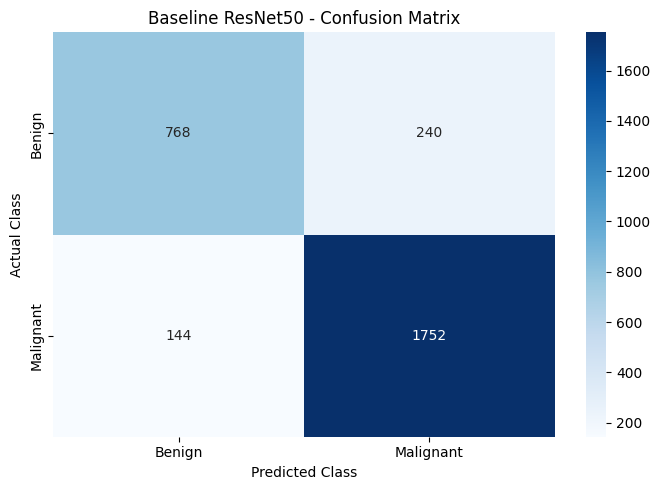

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Baseline ResNet50 - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plt.savefig(
    "baseline_resnet50_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

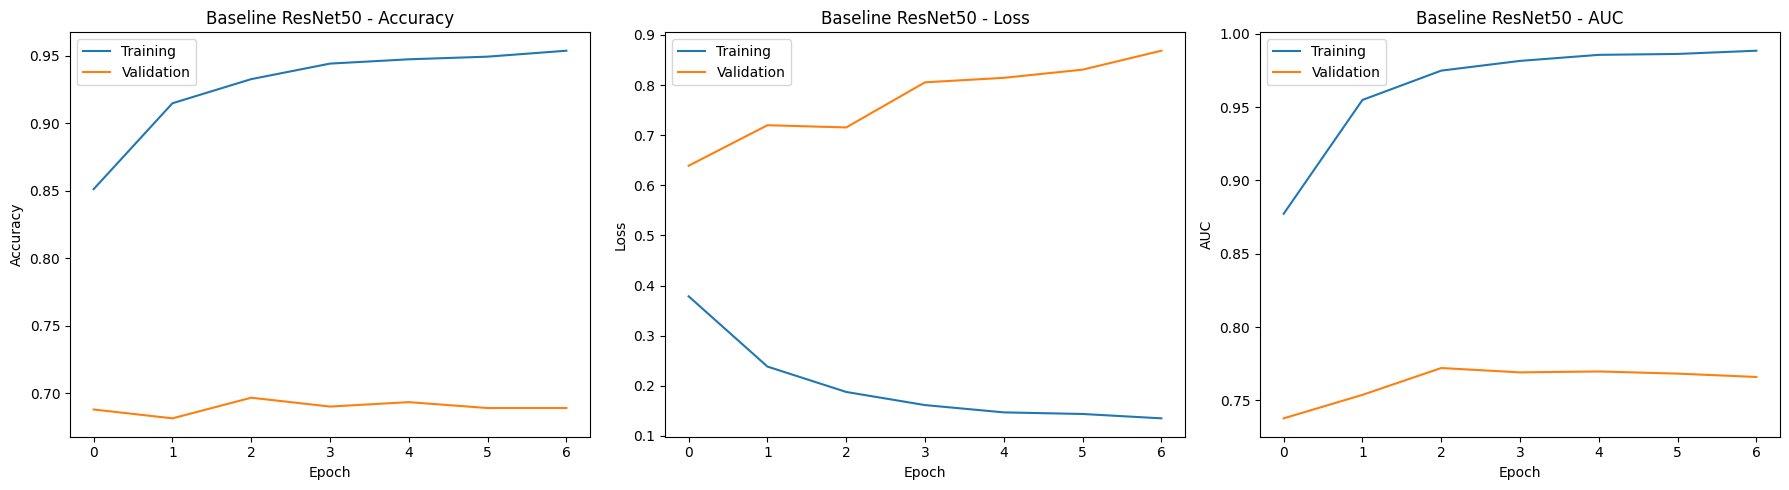

In [ ]:
# ============================================================
# BASELINE TRAINING HISTORY PLOTS
# ============================================================

history_dict = history_baseline.history

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(history_dict["accuracy"], label="Training")
axes[0].plot(history_dict["val_accuracy"], label="Validation")
axes[0].set_title("Baseline ResNet50 - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(history_dict["loss"], label="Training")
axes[1].plot(history_dict["val_loss"], label="Validation")
axes[1].set_title("Baseline ResNet50 - Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

# AUC
axes[2].plot(history_dict["auc"], label="Training")
axes[2].plot(history_dict["val_auc"], label="Validation")
axes[2].set_title("Baseline ResNet50 - AUC")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC")
axes[2].legend()

plt.tight_layout()

plt.savefig(
    "baseline_resnet50_training_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CLASS-WEIGHTED RESNET50
# ============================================================

tf.keras.utils.set_random_seed(42)

# Create a fresh ResNet50 backbone
weighted_base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained backbone
weighted_base_model.trainable = False

# Classification head
inputs = tf.keras.Input(shape=(224, 224, 3))

x = weighted_base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

weighted_model = tf.keras.Model(
    inputs,
    outputs,
    name="ResNet50_ClassWeighted"
)

# Compile
weighted_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

# Callbacks
weighted_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_resnet50_class_weighted.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

print("Class weights:", class_weights)

weighted_model.summary()

Class weights: {0: 1.7076023391812865, 1: 0.7070217917675545}


Model: "ResNet50_ClassWeighted"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ============================================================
# TRAIN CLASS-WEIGHTED RESNET50
# ============================================================

train_generator.reset()
val_generator.reset()

history_weighted = weighted_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=weighted_callbacks,
    verbose=1
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 877ms/step - accuracy: 0.7218 - auc: 0.7958 - loss: 0.5332 - precision: 0.8595 - recall: 0.7209
Epoch 1: val_auc improved from None to 0.73164, saving model to best_resnet50_class_weighted.keras

Epoch 1: finished saving model to best_resnet50_class_weighted.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.8077 - auc: 0.8828 - loss: 0.4349 - precision: 0.9037 - recall: 0.8149 - val_accuracy: 0.6641 - val_auc: 0.7316 - val_loss: 0.7397 - val_precision: 0.8199 - val_recall: 0.6667 - learning_rate: 1.0000e-04
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 863ms/step - accuracy: 0.8958 - auc: 0.9545 - loss: 0.2890 - precision: 0.9447 - recall: 0.9063
Epoch 2: val_auc improved from 0.73164 to 0.75779, saving model to best_resnet50_class_weighted.keras

Epoch 2: finished saving model to best_resnet50_class_weighted.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 127s 990ms/step - accuracy: 0.9036 - auc: 0.9584 - loss: 0.2766 - precision: 0.9464 - recall

In [ ]:
# ============================================================
# CLASS-WEIGHTED RESNET50 - TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

# Reset test generator
test_generator.reset()

# Predict probabilities
weighted_y_prob = weighted_model.predict(
    test_generator,
    verbose=1
).ravel()

# True labels from the test dataframe
weighted_y_true = fold1_test["label"].to_numpy(dtype=int)

# Verify alignment
print("Number of true labels :", len(weighted_y_true))
print("Number of predictions  :", len(weighted_y_prob))

assert len(weighted_y_true) == len(weighted_y_prob), (
    "ERROR: True labels and predictions do not match."
)

# Binary predictions at threshold 0.50
weighted_threshold = 0.50

weighted_y_pred = (
    weighted_y_prob >= weighted_threshold
).astype(int)

# Confusion matrix
weighted_cm = confusion_matrix(
    weighted_y_true,
    weighted_y_pred,
    labels=[0, 1]
)

print("\n" + "=" * 60)
print("CLASS-WEIGHTED CONFUSION MATRIX")
print("=" * 60)

print("                 Predicted")
print("                 Benign  Malignant")
print(
    f"Actual Benign    {weighted_cm[0,0]:>6}   "
    f"{weighted_cm[0,1]:>9}"
)
print(
    f"Actual Malignant {weighted_cm[1,0]:>6}   "
    f"{weighted_cm[1,1]:>9}"
)

# TN, FP, FN, TP
tn, fp, fn, tp = weighted_cm.ravel()

# Overall accuracy
weighted_accuracy = accuracy_score(
    weighted_y_true,
    weighted_y_pred
)

# Class-specific metrics
weighted_precision_benign = precision_score(
    weighted_y_true,
    weighted_y_pred,
    pos_label=0,
    zero_division=0
)

weighted_recall_benign = recall_score(
    weighted_y_true,
    weighted_y_pred,
    pos_label=0,
    zero_division=0
)

weighted_f1_benign = f1_score(
    weighted_y_true,
    weighted_y_pred,
    pos_label=0,
    zero_division=0
)

weighted_precision_malignant = precision_score(
    weighted_y_true,
    weighted_y_pred,
    pos_label=1,
    zero_division=0
)

weighted_recall_malignant = recall_score(
    weighted_y_true,
    weighted_y_pred,
    pos_label=1,
    zero_division=0
)

weighted_f1_malignant = f1_score(
    weighted_y_true,
    weighted_y_pred,
    pos_label=1,
    zero_division=0
)

# Specificity
weighted_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

# Balanced accuracy
weighted_balanced_accuracy = balanced_accuracy_score(
    weighted_y_true,
    weighted_y_pred
)

# Threshold-independent metrics
weighted_roc_auc = roc_auc_score(
    weighted_y_true,
    weighted_y_prob
)

weighted_pr_auc = average_precision_score(
    weighted_y_true,
    weighted_y_prob
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASS-WEIGHTED RESNET50 TEST RESULTS")
print("=" * 60)

print(f"Threshold:            {weighted_threshold:.2f}")
print(
    f"Accuracy:             "
    f"{weighted_accuracy:.4f} "
    f"({weighted_accuracy*100:.2f}%)"
)

print("\nBenign:")
print(f"  Precision:          {weighted_precision_benign:.4f}")
print(f"  Recall:             {weighted_recall_benign:.4f}")
print(f"  F1-score:           {weighted_f1_benign:.4f}")

print("\nMalignant:")
print(
    f"  Precision:          "
    f"{weighted_precision_malignant:.4f}"
)
print(
    f"  Recall:             "
    f"{weighted_recall_malignant:.4f}"
)
print(
    f"  F1-score:           "
    f"{weighted_f1_malignant:.4f}"
)

print("\nOverall:")
print(
    f"  Specificity:        "
    f"{weighted_specificity:.4f}"
)
print(
    f"  Balanced Accuracy:  "
    f"{weighted_balanced_accuracy:.4f}"
)
print(
    f"  ROC-AUC:            "
    f"{weighted_roc_auc:.4f}"
)
print(
    f"  PR-AUC:             "
    f"{weighted_pr_auc:.4f}"
)

print("\nConfusion Matrix Values:")
print(f"  TN = {tn}")
print(f"  FP = {fp}")
print(f"  FN = {fn}")
print(f"  TP = {tp}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        weighted_y_true,
        weighted_y_pred,
        labels=[0, 1],
        target_names=["Benign", "Malignant"],
        digits=4,
        zero_division=0
    )
)

# Save results for later comparison
weighted_test_results = {
    "y_true": weighted_y_true.copy(),
    "y_prob": weighted_y_prob.copy(),
    "y_pred": weighted_y_pred.copy(),
    "threshold": weighted_threshold,
    "confusion_matrix": weighted_cm.copy(),
    "accuracy": weighted_accuracy,
    "precision_benign": weighted_precision_benign,
    "recall_benign": weighted_recall_benign,
    "f1_benign": weighted_f1_benign,
    "precision_malignant": weighted_precision_malignant,
    "recall_malignant": weighted_recall_malignant,
    "f1_malignant": weighted_f1_malignant,
    "specificity": weighted_specificity,
    "balanced_accuracy": weighted_balanced_accuracy,
    "roc_auc": weighted_roc_auc,
    "pr_auc": weighted_pr_auc
}

print("\nClass-weighted results saved.")

91/91 ━━━━━━━━━━━━━━━━━━━━ 58s 583ms/step
Number of true labels : 2904
Number of predictions  : 2904

CLASS-WEIGHTED CONFUSION MATRIX
                 Predicted
                 Benign  Malignant
Actual Benign       852         156
Actual Malignant    232        1664

CLASS-WEIGHTED RESNET50 TEST RESULTS
Threshold:            0.50
Accuracy:             0.8664 (86.64%)

Benign:
  Precision:          0.7860
  Recall:             0.8452
  F1-score:           0.8145

Malignant:
  Precision:          0.9143
  Recall:             0.8776
  F1-score:           0.8956

Overall:
  Specificity:        0.8452
  Balanced Accuracy:  0.8614
  ROC-AUC:            0.9321
  PR-AUC:             0.9640

Confusion Matrix Values:
  TN = 852
  FP = 156
  FN = 232
  TP = 1664

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.7860    0.8452    0.8145      1008
   Malignant     0.9143    0.8776    0.8956      1896

    accuracy                         0.8664      2

In [ ]:
# ============================================================
# VALIDATION-SET THRESHOLD ANALYSIS
# CLASS-WEIGHTED RESNET50
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)
import numpy as np
import pandas as pd

# Reset validation generator
val_generator.reset()

# Generate validation probabilities
val_prob_weighted = weighted_model.predict(
    val_generator,
    verbose=1
).ravel()

# True validation labels
val_true = val_df["label"].to_numpy(dtype=int)

# Safety check
print("Validation labels:", len(val_true))
print("Validation predictions:", len(val_prob_weighted))

assert len(val_true) == len(val_prob_weighted)

# ------------------------------------------------------------
# Evaluate multiple thresholds
# ------------------------------------------------------------

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    val_pred = (val_prob_weighted >= threshold).astype(int)

    acc = accuracy_score(val_true, val_pred)

    sensitivity = recall_score(
        val_true,
        val_pred,
        pos_label=1,
        zero_division=0
    )

    specificity = recall_score(
        val_true,
        val_pred,
        pos_label=0,
        zero_division=0
    )

    precision = precision_score(
        val_true,
        val_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        val_true,
        val_pred,
        pos_label=1,
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        val_true,
        val_pred
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": acc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1": f1,
        "Balanced Accuracy": balanced_acc
    })

threshold_df = pd.DataFrame(threshold_results)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

display(
    threshold_df.style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "Specificity": "{:.4f}",
        "Precision": "{:.4f}",
        "F1": "{:.4f}",
        "Balanced Accuracy": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Find threshold with maximum validation balanced accuracy
# ------------------------------------------------------------

best_threshold_row = threshold_df.loc[
    threshold_df["Balanced Accuracy"].idxmax()
]

best_threshold = float(best_threshold_row["Threshold"])

print("\n" + "=" * 60)
print("BEST VALIDATION THRESHOLD")
print("=" * 60)

print(f"Threshold:          {best_threshold:.2f}")
print(f"Accuracy:           {best_threshold_row['Accuracy']:.4f}")
print(f"Sensitivity:        {best_threshold_row['Sensitivity']:.4f}")
print(f"Specificity:        {best_threshold_row['Specificity']:.4f}")
print(f"Precision:          {best_threshold_row['Precision']:.4f}")
print(f"F1-score:           {best_threshold_row['F1']:.4f}")
print(f"Balanced Accuracy:  {best_threshold_row['Balanced Accuracy']:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 766ms/step
Validation labels: 917
Validation predictions: 917


,Threshold,Accuracy,Sensitivity,Specificity,Precision,F1,Balanced Accuracy
0,0.10,0.6968,0.8551,0.3273,0.7480,0.7980,0.5912
1,0.15,0.7012,0.8349,0.3891,0.7614,0.7964,0.6120
2,0.20,0.7034,0.8162,0.4400,0.7729,0.7939,0.6281
3,0.25,0.7012,0.7944,0.4836,0.7822,0.7883,0.6390
4,0.30,0.6979,0.7710,0.5273,0.7920,0.7814,0.6492
5,0.35,0.7001,0.7508,0.5818,0.8074,0.7780,0.6663
6,0.40,0.6947,0.7290,0.6145,0.8153,0.7697,0.6718
7,0.45,0.6936,0.7134,0.6473,0.8252,0.7652,0.6803
8,0.50,0.6925,0.6947,0.6873,0.8383,0.7598,0.6910
9,0.55,0.6936,0.6729,0.7418,0.8588,0.7546,0.7074



BEST VALIDATION THRESHOLD
Threshold:          0.75
Accuracy:           0.6696
Sensitivity:        0.5779
Specificity:        0.8836
Precision:          0.9206
F1-score:           0.7100
Balanced Accuracy:  0.7308


In [ ]:
# ============================================================
# CLASS-WEIGHTED MODEL - TEST EVALUATION AT VALIDATION-SELECTED
# THRESHOLD
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

# Use the threshold selected ONLY from the validation set
final_threshold = best_threshold

print("Validation-selected threshold:", final_threshold)

# Use the predictions already generated for the untouched test set
test_y_true = weighted_test_results["y_true"]
test_y_prob = weighted_test_results["y_prob"]

# Apply validation-selected threshold
test_y_pred_threshold = (
    test_y_prob >= final_threshold
).astype(int)

# Confusion matrix
cm_threshold = confusion_matrix(
    test_y_true,
    test_y_pred_threshold,
    labels=[0, 1]
)

tn, fp, fn, tp = cm_threshold.ravel()

# Metrics
accuracy_threshold = accuracy_score(
    test_y_true,
    test_y_pred_threshold
)

precision_benign_threshold = precision_score(
    test_y_true,
    test_y_pred_threshold,
    pos_label=0,
    zero_division=0
)

recall_benign_threshold = recall_score(
    test_y_true,
    test_y_pred_threshold,
    pos_label=0,
    zero_division=0
)

f1_benign_threshold = f1_score(
    test_y_true,
    test_y_pred_threshold,
    pos_label=0,
    zero_division=0
)

precision_malignant_threshold = precision_score(
    test_y_true,
    test_y_pred_threshold,
    pos_label=1,
    zero_division=0
)

recall_malignant_threshold = recall_score(
    test_y_true,
    test_y_pred_threshold,
    pos_label=1,
    zero_division=0
)

f1_malignant_threshold = f1_score(
    test_y_true,
    test_y_pred_threshold,
    pos_label=1,
    zero_division=0
)

specificity_threshold = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

balanced_accuracy_threshold = balanced_accuracy_score(
    test_y_true,
    test_y_pred_threshold
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TEST RESULTS USING VALIDATION-SELECTED THRESHOLD")
print("=" * 60)

print(f"Threshold:            {final_threshold:.2f}")

print("\nConfusion Matrix:")
print("                 Predicted")
print("                 Benign  Malignant")
print(
    f"Actual Benign    {tn:>6}   {fp:>9}"
)
print(
    f"Actual Malignant {fn:>6}   {tp:>9}"
)

print("\nMetrics:")
print(f"Accuracy:             {accuracy_threshold:.4f}")
print(f"Benign Precision:     {precision_benign_threshold:.4f}")
print(f"Benign Recall:        {recall_benign_threshold:.4f}")
print(f"Benign F1:            {f1_benign_threshold:.4f}")
print(f"Malignant Precision:  {precision_malignant_threshold:.4f}")
print(f"Malignant Recall:     {recall_malignant_threshold:.4f}")
print(f"Malignant F1:         {f1_malignant_threshold:.4f}")
print(f"Specificity:          {specificity_threshold:.4f}")
print(f"Balanced Accuracy:    {balanced_accuracy_threshold:.4f}")

Validation-selected threshold: 0.7500000000000002

TEST RESULTS USING VALIDATION-SELECTED THRESHOLD
Threshold:            0.75

Confusion Matrix:
                 Predicted
                 Benign  Malignant
Actual Benign       948          60
Actual Malignant    494        1402

Metrics:
Accuracy:             0.8092
Benign Precision:     0.6574
Benign Recall:        0.9405
Benign F1:            0.7739
Malignant Precision:  0.9590
Malignant Recall:     0.7395
Malignant F1:         0.8350
Specificity:          0.9405
Balanced Accuracy:    0.8400


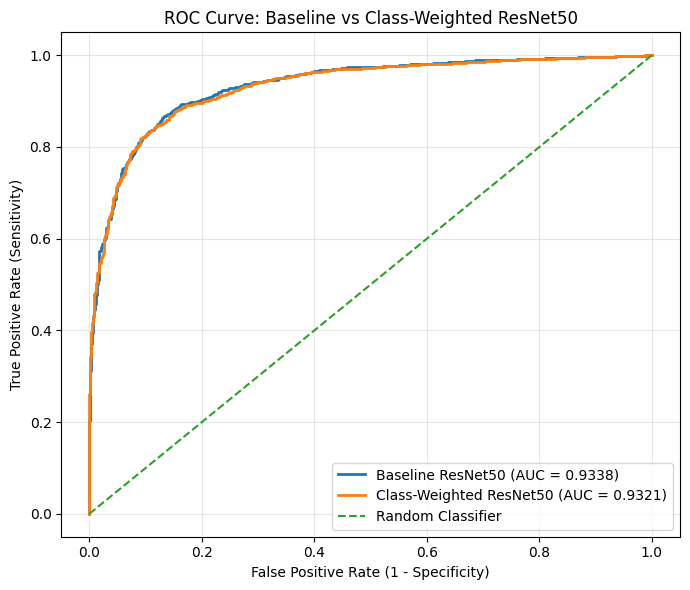

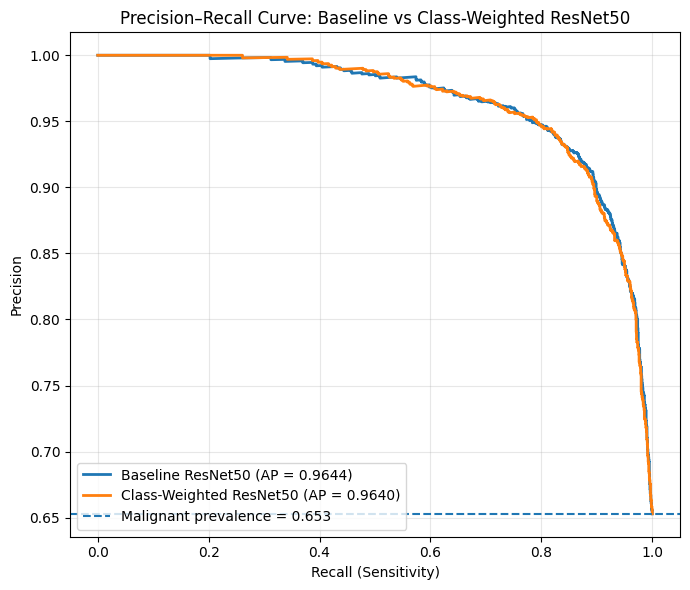

ROC / PRECISION-RECALL COMPARISON
Baseline ROC-AUC:          0.9338
Class-Weighted ROC-AUC:    0.9321

Baseline PR-AUC (AP):      0.9644
Class-Weighted PR-AUC:     0.9640

Malignant prevalence:      0.6529

Plots saved successfully.


In [ ]:
# ============================================================
# ROC CURVE AND PRECISION-RECALL CURVE
# BASELINE VS CLASS-WEIGHTED RESNET50
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ------------------------------------------------------------
# 1. ROC curves
# ------------------------------------------------------------

baseline_fpr, baseline_tpr, _ = roc_curve(
    baseline_test_results["y_true"],
    baseline_test_results["y_prob"]
)

weighted_fpr, weighted_tpr, _ = roc_curve(
    weighted_test_results["y_true"],
    weighted_test_results["y_prob"]
)

baseline_roc_auc = auc(
    baseline_fpr,
    baseline_tpr
)

weighted_roc_auc_curve = auc(
    weighted_fpr,
    weighted_tpr
)

plt.figure(figsize=(7, 6))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    linewidth=2,
    label=f"Baseline ResNet50 (AUC = {baseline_roc_auc:.4f})"
)

plt.plot(
    weighted_fpr,
    weighted_tpr,
    linewidth=2,
    label=f"Class-Weighted ResNet50 (AUC = {weighted_roc_auc_curve:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve: Baseline vs Class-Weighted ResNet50")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "roc_curve_baseline_vs_class_weighted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 2. Precision-Recall curves
# ------------------------------------------------------------

baseline_precision, baseline_recall, _ = precision_recall_curve(
    baseline_test_results["y_true"],
    baseline_test_results["y_prob"]
)

weighted_precision, weighted_recall, _ = precision_recall_curve(
    weighted_test_results["y_true"],
    weighted_test_results["y_prob"]
)

baseline_pr_auc = average_precision_score(
    baseline_test_results["y_true"],
    baseline_test_results["y_prob"]
)

weighted_pr_auc = average_precision_score(
    weighted_test_results["y_true"],
    weighted_test_results["y_prob"]
)

plt.figure(figsize=(7, 6))

plt.plot(
    baseline_recall,
    baseline_precision,
    linewidth=2,
    label=f"Baseline ResNet50 (AP = {baseline_pr_auc:.4f})"
)

plt.plot(
    weighted_recall,
    weighted_precision,
    linewidth=2,
    label=f"Class-Weighted ResNet50 (AP = {weighted_pr_auc:.4f})"
)

# Positive-class prevalence baseline
positive_prevalence = (
    baseline_test_results["y_true"].sum()
    / len(baseline_test_results["y_true"])
)

plt.axhline(
    positive_prevalence,
    linestyle="--",
    linewidth=1.5,
    label=f"Malignant prevalence = {positive_prevalence:.3f}"
)

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve: Baseline vs Class-Weighted ResNet50")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "precision_recall_curve_baseline_vs_class_weighted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 3. Print comparison
# ------------------------------------------------------------

print("=" * 65)
print("ROC / PRECISION-RECALL COMPARISON")
print("=" * 65)

print(f"Baseline ROC-AUC:          {baseline_roc_auc:.4f}")
print(f"Class-Weighted ROC-AUC:    {weighted_roc_auc_curve:.4f}")

print()

print(f"Baseline PR-AUC (AP):      {baseline_pr_auc:.4f}")
print(f"Class-Weighted PR-AUC:     {weighted_pr_auc:.4f}")

print()

print(f"Malignant prevalence:      {positive_prevalence:.4f}")

print("\nPlots saved successfully.")

In [ ]:
# ============================================================
# INSPECT RESNET50 LAYERS BEFORE FINE-TUNING
# ============================================================

for i, layer in enumerate(weighted_model.layers):
    print(f"{i:3d} | {layer.name:35s} | "
          f"{layer.__class__.__name__:25s} | "
          f"trainable={layer.trainable}")

  0 | input_layer_5                       | InputLayer                | trainable=True
  1 | resnet50                            | Functional                | trainable=False
  2 | global_average_pooling2d_2          | GlobalAveragePooling2D    | trainable=True
  3 | dense_4                             | Dense                     | trainable=True
  4 | dense_5                             | Dense                     | trainable=True


In [ ]:
# ============================================================
# INSPECT INTERNAL RESNET50 LAYERS
# ============================================================

resnet_backbone = weighted_model.get_layer("resnet50")

print("Total internal ResNet50 layers:", len(resnet_backbone.layers))
print("\nLast 40 internal layers:\n")

for i, layer in enumerate(resnet_backbone.layers[-40:],
                          start=len(resnet_backbone.layers) - 40):
    print(
        f"{i:3d} | "
        f"{layer.name:35s} | "
        f"{layer.__class__.__name__:25s} | "
        f"trainable={layer.trainable}"
    )

Total internal ResNet50 layers: 175

Last 40 internal layers:

135 | conv4_block6_1_relu                 | Activation                | trainable=False
136 | conv4_block6_2_conv                 | Conv2D                    | trainable=False
137 | conv4_block6_2_bn                   | BatchNormalization        | trainable=False
138 | conv4_block6_2_relu                 | Activation                | trainable=False
139 | conv4_block6_3_conv                 | Conv2D                    | trainable=False
140 | conv4_block6_3_bn                   | BatchNormalization        | trainable=False
141 | conv4_block6_add                    | Add                       | trainable=False
142 | conv4_block6_out                    | Activation                | trainable=False
143 | conv5_block1_1_conv                 | Conv2D                    | trainable=False
144 | conv5_block1_1_bn                   | BatchNormalization        | trainable=False
145 | conv5_block1_1_relu                 | Activation   

In [ ]:
# ============================================================
# FINE-TUNED RESNET50
# Unfreeze only the final ResNet50 residual stage (conv5)
# ============================================================

import tensorflow as tf

# ------------------------------------------------------------
# 1. Create an independent copy of the class-weighted model
# ------------------------------------------------------------
fine_tune_model = tf.keras.models.clone_model(weighted_model)

# Copy the trained class-weighted model weights
fine_tune_model.set_weights(weighted_model.get_weights())

# ------------------------------------------------------------
# 2. Access the ResNet50 backbone
# ------------------------------------------------------------
fine_tune_backbone = fine_tune_model.get_layer("resnet50")

# First freeze the complete backbone
fine_tune_backbone.trainable = True

# Freeze all internal layers
for layer in fine_tune_backbone.layers:
    layer.trainable = False

# ------------------------------------------------------------
# 3. Unfreeze only the final residual block: conv5
# ------------------------------------------------------------
for layer in fine_tune_backbone.layers:
    if layer.name.startswith("conv5_"):
        layer.trainable = True

    # Keep Batch Normalization frozen
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# ------------------------------------------------------------
# 4. Keep classification head trainable
# ------------------------------------------------------------
for layer in fine_tune_model.layers:
    if layer.name != "resnet50":
        layer.trainable = True

# ------------------------------------------------------------
# 5. Compile with a small learning rate
# ------------------------------------------------------------
fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

# ------------------------------------------------------------
# 6. Check trainable layers
# ------------------------------------------------------------
print("=" * 65)
print("FINE-TUNING CONFIGURATION")
print("=" * 65)

print("Trainable ResNet50 layers:")
for layer in fine_tune_backbone.layers:
    if layer.trainable:
        print(
            f"{layer.name:35s} | "
            f"{layer.__class__.__name__}"
        )

print("\nTotal parameters:",
      fine_tune_model.count_params())

print(
    "Trainable parameters:",
    sum(
        tf.size(w).numpy()
        for w in fine_tune_model.trainable_weights
    )
)

print(
    "Non-trainable parameters:",
    sum(
        tf.size(w).numpy()
        for w in fine_tune_model.non_trainable_weights
    )
)

FINE-TUNING CONFIGURATION
Trainable ResNet50 layers:
conv5_block1_1_conv                 | Conv2D
conv5_block1_1_relu                 | Activation
conv5_block1_2_conv                 | Conv2D
conv5_block1_2_relu                 | Activation
conv5_block1_0_conv                 | Conv2D
conv5_block1_3_conv                 | Conv2D
conv5_block1_add                    | Add
conv5_block1_out                    | Activation
conv5_block2_1_conv                 | Conv2D
conv5_block2_1_relu                 | Activation
conv5_block2_2_conv                 | Conv2D
conv5_block2_2_relu                 | Activation
conv5_block2_3_conv                 | Conv2D
conv5_block2_add                    | Add
conv5_block2_out                    | Activation
conv5_block3_1_conv                 | Conv2D
conv5_block3_1_relu                 | Activation
conv5_block3_2_conv                 | Conv2D
conv5_block3_2_relu                 | Activation
conv5_block3_3_conv                 | Conv2D
conv5_block3_add     

In [ ]:
# ============================================================
# TRAIN FINE-TUNED RESNET50
# ============================================================

# Reset generators
train_generator.reset()
val_generator.reset()

# Callbacks for fine-tuning
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_resnet50_finetuned.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

# Fine-tune
history_finetune = fine_tune_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks,
    verbose=1
)

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.9472 - auc: 0.9837 - loss: 0.1686 - precision: 0.9691 - recall: 0.9552
Epoch 1: val_auc improved from None to 0.79805, saving model to best_resnet50_finetuned.keras

Epoch 1: finished saving model to best_resnet50_finetuned.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9506 - auc: 0.9877 - loss: 0.1470 - precision: 0.9732 - recall: 0.9564 - val_accuracy: 0.7176 - val_auc: 0.7981 - val_loss: 1.0160 - val_precision: 0.8748 - val_recall: 0.6963 - learning_rate: 1.0000e-05
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 930ms/step - accuracy: 0.9645 - auc: 0.9937 - loss: 0.1050 - precision: 0.9803 - recall: 0.9689
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_auc improved from 0.79805 to 0.80378, saving model to best_resnet50_finetuned.keras

Epoch 2: finished saving model to best_resnet50_finetuned.keras
128/128 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9704 - a

In [48]:
# ============================================================
# FINE-TUNED RESNET50 - TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

# Reset test generator
test_generator.reset()

# Generate probabilities
finetune_y_prob = fine_tune_model.predict(
    test_generator,
    verbose=1
).ravel()

# True test labels
finetune_y_true = fold1_test["label"].to_numpy(dtype=int)

# Verify alignment
print("Number of true labels :", len(finetune_y_true))
print("Number of predictions :", len(finetune_y_prob))

assert len(finetune_y_true) == len(finetune_y_prob), (
    "ERROR: Number of true labels and predictions do not match."
)

# Default threshold
finetune_threshold = 0.50

finetune_y_pred = (
    finetune_y_prob >= finetune_threshold
).astype(int)

# Confusion matrix
finetune_cm = confusion_matrix(
    finetune_y_true,
    finetune_y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = finetune_cm.ravel()

# Metrics
finetune_accuracy = accuracy_score(
    finetune_y_true,
    finetune_y_pred
)

finetune_precision_benign = precision_score(
    finetune_y_true,
    finetune_y_pred,
    pos_label=0,
    zero_division=0
)

finetune_recall_benign = recall_score(
    finetune_y_true,
    finetune_y_pred,
    pos_label=0,
    zero_division=0
)

finetune_f1_benign = f1_score(
    finetune_y_true,
    finetune_y_pred,
    pos_label=0,
    zero_division=0
)

finetune_precision_malignant = precision_score(
    finetune_y_true,
    finetune_y_pred,
    pos_label=1,
    zero_division=0
)

finetune_recall_malignant = recall_score(
    finetune_y_true,
    finetune_y_pred,
    pos_label=1,
    zero_division=0
)

finetune_f1_malignant = f1_score(
    finetune_y_true,
    finetune_y_pred,
    pos_label=1,
    zero_division=0
)

finetune_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

finetune_balanced_accuracy = balanced_accuracy_score(
    finetune_y_true,
    finetune_y_pred
)

finetune_roc_auc = roc_auc_score(
    finetune_y_true,
    finetune_y_prob
)

finetune_pr_auc = average_precision_score(
    finetune_y_true,
    finetune_y_prob
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FINE-TUNED RESNET50 TEST RESULTS")
print("=" * 65)

print(f"Threshold:            {finetune_threshold:.2f}")

print("\nConfusion Matrix:")
print("                 Predicted")
print("                 Benign  Malignant")
print(
    f"Actual Benign    {tn:>6}   {fp:>9}"
)
print(
    f"Actual Malignant {fn:>6}   {tp:>9}"
)

print("\nMetrics:")
print(
    f"Accuracy:             "
    f"{finetune_accuracy:.4f} "
    f"({finetune_accuracy*100:.2f}%)"
)

print(
    f"Benign Precision:     "
    f"{finetune_precision_benign:.4f}"
)
print(
    f"Benign Recall:        "
    f"{finetune_recall_benign:.4f}"
)
print(
    f"Benign F1:            "
    f"{finetune_f1_benign:.4f}"
)

print(
    f"Malignant Precision:  "
    f"{finetune_precision_malignant:.4f}"
)
print(
    f"Malignant Recall:     "
    f"{finetune_recall_malignant:.4f}"
)
print(
    f"Malignant F1:         "
    f"{finetune_f1_malignant:.4f}"
)

print(
    f"Specificity:          "
    f"{finetune_specificity:.4f}"
)
print(
    f"Balanced Accuracy:    "
    f"{finetune_balanced_accuracy:.4f}"
)
print(
    f"ROC-AUC:              "
    f"{finetune_roc_auc:.4f}"
)
print(
    f"PR-AUC:               "
    f"{finetune_pr_auc:.4f}"
)

print("\nConfusion Matrix Values:")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

print("\n" + "=" * 65)
print("CLASSIFICATION REPORT")
print("=" * 65)

print(
    classification_report(
        finetune_y_true,
        finetune_y_pred,
        labels=[0, 1],
        target_names=["Benign", "Malignant"],
        digits=4,
        zero_division=0
    )
)

# Save results
finetune_test_results = {
    "y_true": finetune_y_true.copy(),
    "y_prob": finetune_y_prob.copy(),
    "y_pred": finetune_y_pred.copy(),
    "threshold": finetune_threshold,
    "confusion_matrix": finetune_cm.copy(),
    "accuracy": finetune_accuracy,
    "precision_benign": finetune_precision_benign,
    "recall_benign": finetune_recall_benign,
    "f1_benign": finetune_f1_benign,
    "precision_malignant": finetune_precision_malignant,
    "recall_malignant": finetune_recall_malignant,
    "f1_malignant": finetune_f1_malignant,
    "specificity": finetune_specificity,
    "balanced_accuracy": finetune_balanced_accuracy,
    "roc_auc": finetune_roc_auc,
    "pr_auc": finetune_pr_auc
}

print("\nFine-tuned results saved.")

91/91 ━━━━━━━━━━━━━━━━━━━━ 75s 740ms/step
Number of true labels : 2904
Number of predictions : 2904

FINE-TUNED RESNET50 TEST RESULTS
Threshold:            0.50

Confusion Matrix:
                 Predicted
                 Benign  Malignant
Actual Benign       892         116
Actual Malignant    261        1635

Metrics:
Accuracy:             0.8702 (87.02%)
Benign Precision:     0.7736
Benign Recall:        0.8849
Benign F1:            0.8255
Malignant Precision:  0.9338
Malignant Recall:     0.8623
Malignant F1:         0.8966
Specificity:          0.8849
Balanced Accuracy:    0.8736
ROC-AUC:              0.9426
PR-AUC:               0.9704

Confusion Matrix Values:
TN = 892
FP = 116
FN = 261
TP = 1635

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.7736    0.8849    0.8255      1008
   Malignant     0.9338    0.8623    0.8966      1896

    accuracy                         0.8702      2904
   macro avg     0.8537    0.8736    0.8611 

FINAL MODEL COMPARISON


,Model,Accuracy,Balanced Accuracy,Specificity,Malignant Recall,Benign Recall,Macro F1,ROC-AUC,PR-AUC
0,Baseline ResNet50,0.8678,0.8430,0.7619,0.9241,0.7619,0.8506,0.9338,0.9644
1,Class-Weighted ResNet50,0.8664,0.8614,0.8452,0.8776,0.8452,0.8551,0.9321,0.9640
2,Fine-Tuned ResNet50,0.8702,0.8736,0.8849,0.8623,0.8849,0.8611,0.9426,0.9704



Comparison table saved as: final_model_comparison.csv


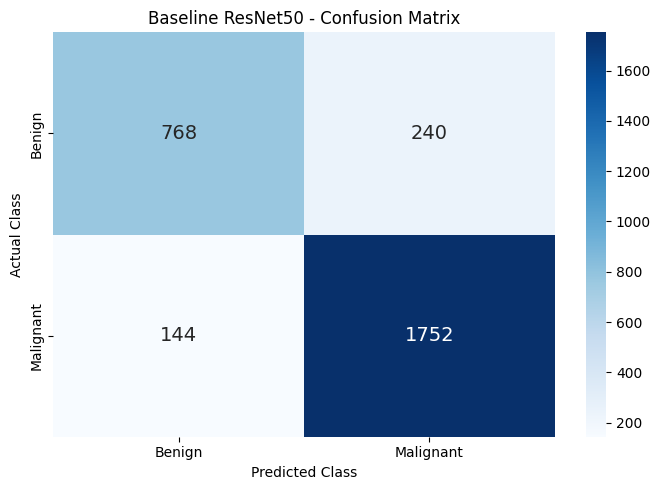

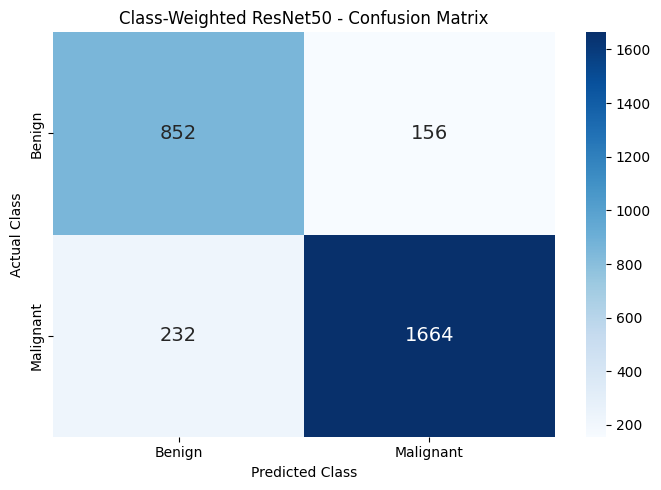

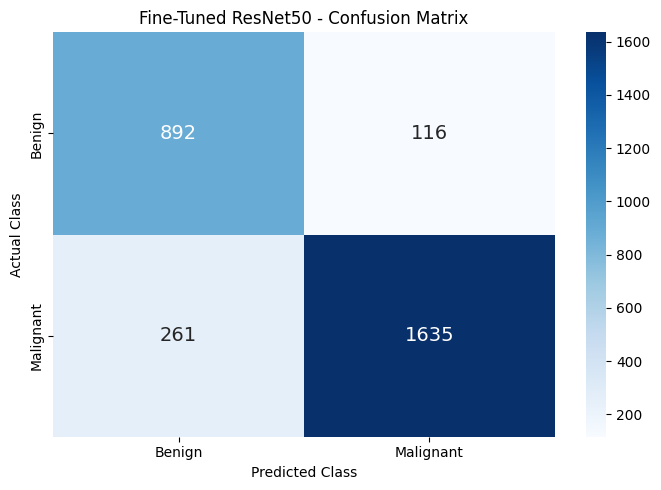

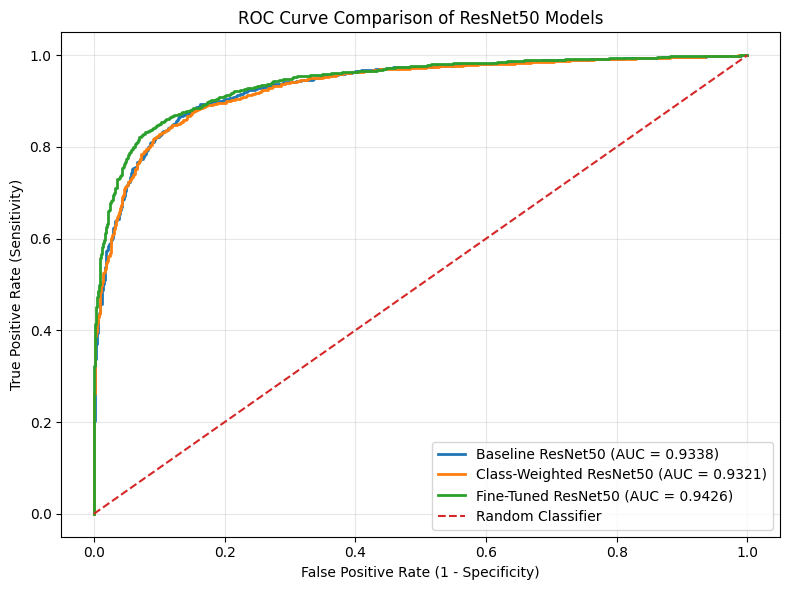

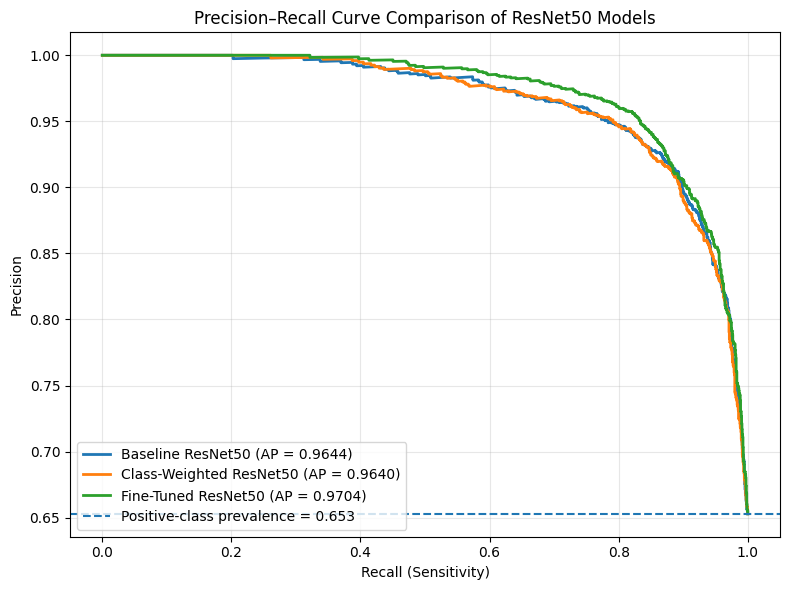

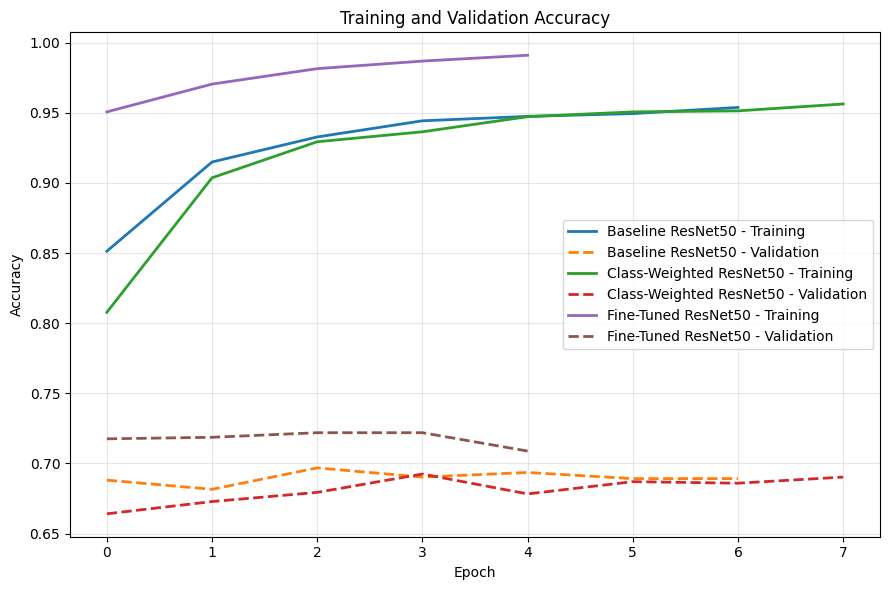

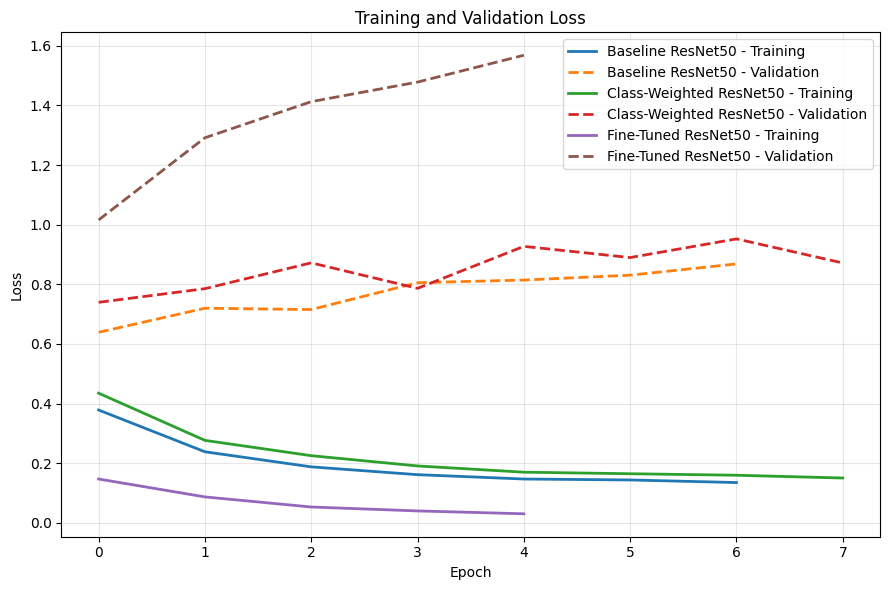

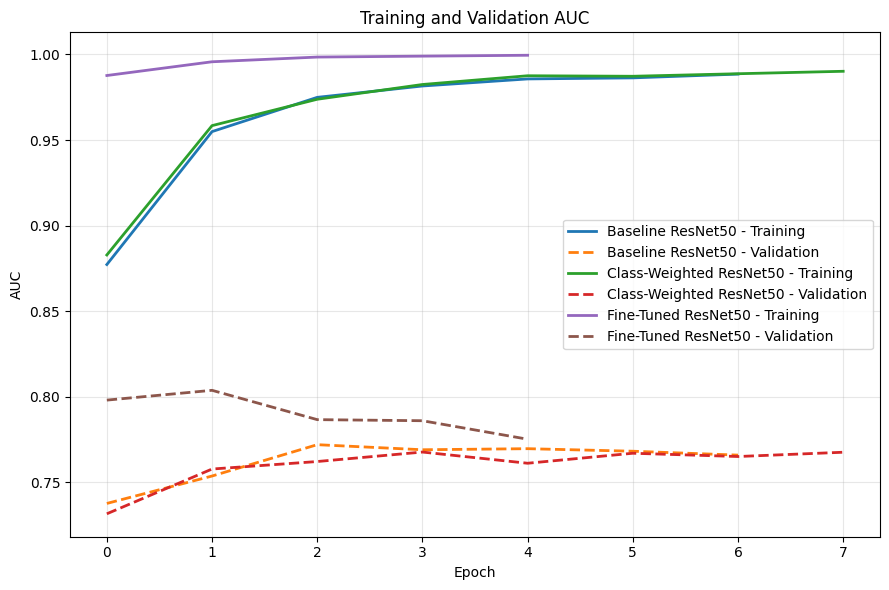


ALL COMPARISON FIGURES GENERATED
Saved files:
1. final_model_comparison.csv
2. roc_curve_three_models.png
3. precision_recall_curve_three_models.png
4. training_validation_accuracy_three_models.png
5. training_validation_loss_three_models.png
6. training_validation_auc_three_models.png


In [49]:
# ============================================================
# FINAL COMPARISON: THREE RESNET50 EXPERIMENTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ------------------------------------------------------------
# 1. Create final comparison table
# ------------------------------------------------------------

comparison_results = pd.DataFrame([
    {
        "Model": "Baseline ResNet50",
        "Accuracy": baseline_test_results["accuracy"],
        "Balanced Accuracy": baseline_test_results["balanced_accuracy"],
        "Specificity": baseline_test_results["specificity"],
        "Malignant Recall": baseline_test_results["recall_malignant"],
        "Benign Recall": baseline_test_results["recall_benign"],
        "Macro F1": (
            baseline_test_results["f1_benign"] +
            baseline_test_results["f1_malignant"]
        ) / 2,
        "ROC-AUC": baseline_test_results["roc_auc"],
        "PR-AUC": baseline_test_results["pr_auc"]
    },
    {
        "Model": "Class-Weighted ResNet50",
        "Accuracy": weighted_test_results["accuracy"],
        "Balanced Accuracy": weighted_test_results["balanced_accuracy"],
        "Specificity": weighted_test_results["specificity"],
        "Malignant Recall": weighted_test_results["recall_malignant"],
        "Benign Recall": weighted_test_results["recall_benign"],
        "Macro F1": (
            weighted_test_results["f1_benign"] +
            weighted_test_results["f1_malignant"]
        ) / 2,
        "ROC-AUC": weighted_test_results["roc_auc"],
        "PR-AUC": weighted_test_results["pr_auc"]
    },
    {
        "Model": "Fine-Tuned ResNet50",
        "Accuracy": finetune_test_results["accuracy"],
        "Balanced Accuracy": finetune_test_results["balanced_accuracy"],
        "Specificity": finetune_test_results["specificity"],
        "Malignant Recall": finetune_test_results["recall_malignant"],
        "Benign Recall": finetune_test_results["recall_benign"],
        "Macro F1": (
            finetune_test_results["f1_benign"] +
            finetune_test_results["f1_malignant"]
        ) / 2,
        "ROC-AUC": finetune_test_results["roc_auc"],
        "PR-AUC": finetune_test_results["pr_auc"]
    }
])

print("=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)

display(
    comparison_results.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Specificity": "{:.4f}",
        "Malignant Recall": "{:.4f}",
        "Benign Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}"
    })
)

# Save table
comparison_results.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("\nComparison table saved as: final_model_comparison.csv")


# ============================================================
# 2. Confusion Matrix plots
# ============================================================

model_names = [
    "Baseline ResNet50",
    "Class-Weighted ResNet50",
    "Fine-Tuned ResNet50"
]

confusion_matrices = [
    baseline_test_results["confusion_matrix"],
    weighted_test_results["confusion_matrix"],
    finetune_test_results["confusion_matrix"]
]

for model_name, matrix in zip(model_names, confusion_matrices):

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"],
        annot_kws={"size": 14}
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()

    filename = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "")
        + "_confusion_matrix.png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 3. Combined ROC Curve
# ============================================================

baseline_true = baseline_test_results["y_true"]
baseline_prob = baseline_test_results["y_prob"]

weighted_true = weighted_test_results["y_true"]
weighted_prob = weighted_test_results["y_prob"]

finetune_true = finetune_test_results["y_true"]
finetune_prob = finetune_test_results["y_prob"]


baseline_fpr, baseline_tpr, _ = roc_curve(
    baseline_true,
    baseline_prob
)

weighted_fpr, weighted_tpr, _ = roc_curve(
    weighted_true,
    weighted_prob
)

finetune_fpr, finetune_tpr, _ = roc_curve(
    finetune_true,
    finetune_prob
)

baseline_auc = auc(baseline_fpr, baseline_tpr)
weighted_auc = auc(weighted_fpr, weighted_tpr)
finetune_auc = auc(finetune_fpr, finetune_tpr)


plt.figure(figsize=(8, 6))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    linewidth=2,
    label=f"Baseline ResNet50 (AUC = {baseline_auc:.4f})"
)

plt.plot(
    weighted_fpr,
    weighted_tpr,
    linewidth=2,
    label=f"Class-Weighted ResNet50 (AUC = {weighted_auc:.4f})"
)

plt.plot(
    finetune_fpr,
    finetune_tpr,
    linewidth=2,
    label=f"Fine-Tuned ResNet50 (AUC = {finetune_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve Comparison of ResNet50 Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "roc_curve_three_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 4. Combined Precision-Recall Curve
# ============================================================

baseline_precision, baseline_recall, _ = precision_recall_curve(
    baseline_true,
    baseline_prob
)

weighted_precision, weighted_recall, _ = precision_recall_curve(
    weighted_true,
    weighted_prob
)

finetune_precision, finetune_recall, _ = precision_recall_curve(
    finetune_true,
    finetune_prob
)

baseline_ap = average_precision_score(
    baseline_true,
    baseline_prob
)

weighted_ap = average_precision_score(
    weighted_true,
    weighted_prob
)

finetune_ap = average_precision_score(
    finetune_true,
    finetune_prob
)

positive_prevalence = baseline_true.mean()


plt.figure(figsize=(8, 6))

plt.plot(
    baseline_recall,
    baseline_precision,
    linewidth=2,
    label=f"Baseline ResNet50 (AP = {baseline_ap:.4f})"
)

plt.plot(
    weighted_recall,
    weighted_precision,
    linewidth=2,
    label=f"Class-Weighted ResNet50 (AP = {weighted_ap:.4f})"
)

plt.plot(
    finetune_recall,
    finetune_precision,
    linewidth=2,
    label=f"Fine-Tuned ResNet50 (AP = {finetune_ap:.4f})"
)

plt.axhline(
    positive_prevalence,
    linestyle="--",
    linewidth=1.5,
    label=f"Positive-class prevalence = {positive_prevalence:.3f}"
)

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison of ResNet50 Models")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "precision_recall_curve_three_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. Training / Validation curves
# ============================================================

histories = {
    "Baseline ResNet50": history_baseline.history,
    "Class-Weighted ResNet50": history_weighted.history,
    "Fine-Tuned ResNet50": history_finetune.history
}

# -------------------------
# Accuracy curves
# -------------------------

plt.figure(figsize=(9, 6))

for name, history in histories.items():
    plt.plot(
        history["accuracy"],
        linewidth=2,
        label=f"{name} - Training"
    )

    plt.plot(
        history["val_accuracy"],
        linestyle="--",
        linewidth=2,
        label=f"{name} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "training_validation_accuracy_three_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------
# Loss curves
# -------------------------

plt.figure(figsize=(9, 6))

for name, history in histories.items():

    plt.plot(
        history["loss"],
        linewidth=2,
        label=f"{name} - Training"
    )

    plt.plot(
        history["val_loss"],
        linestyle="--",
        linewidth=2,
        label=f"{name} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "training_validation_loss_three_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------
# AUC curves
# -------------------------

plt.figure(figsize=(9, 6))

for name, history in histories.items():

    plt.plot(
        history["auc"],
        linewidth=2,
        label=f"{name} - Training"
    )

    plt.plot(
        history["val_auc"],
        linestyle="--",
        linewidth=2,
        label=f"{name} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training and Validation AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "training_validation_auc_three_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\n" + "=" * 90)
print("ALL COMPARISON FIGURES GENERATED")
print("=" * 90)

print("Saved files:")
print("1. final_model_comparison.csv")
print("2. roc_curve_three_models.png")
print("3. precision_recall_curve_three_models.png")
print("4. training_validation_accuracy_three_models.png")
print("5. training_validation_loss_three_models.png")
print("6. training_validation_auc_three_models.png")

In [54]:
# ============================================================
# CLASS-SPECIFIC GRAD-CAM FUNCTION
# ============================================================

def make_gradcam_heatmap_class_specific(
    img_array,
    model,
    target_class
):
    """
    Generate Grad-CAM for a specific binary class.

    target_class:
        0 = Benign
        1 = Malignant
    """

    # Access backbone
    backbone = model.get_layer("resnet50")

    # Last convolutional layer
    last_conv = None

    for layer in reversed(backbone.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer
            break

    # Existing classification layers
    gap = model.get_layer("global_average_pooling2d_2")
    dense = model.get_layer("dense_4")
    output_layer = model.get_layer("dense_5")

    # Build Grad-CAM computational model
    x = gap(backbone.output)
    x = dense(x)
    output = output_layer(x)

    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[last_conv.output, output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            img_array,
            training=False
        )

        malignant_probability = predictions[:, 0]

        # Target score depends on class
        if target_class == 1:
            target_score = malignant_probability
        else:
            target_score = 1.0 - malignant_probability

    # Gradient
    grads = tape.gradient(
        target_score,
        conv_outputs
    )

    # Global average of gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weighted feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Keep positive contributions
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(heatmap)

    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        heatmap
    )

    return heatmap.numpy()

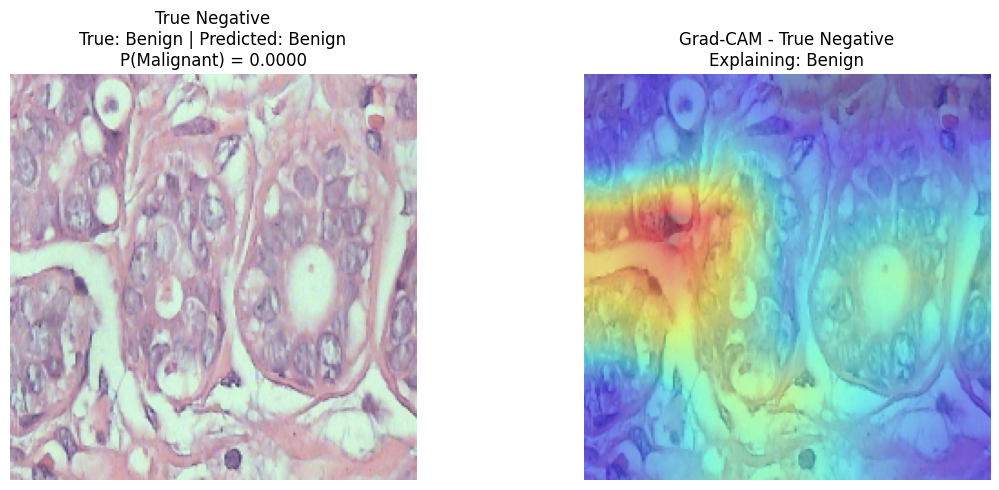

Saved: gradcam_class_specific_true_negative.png


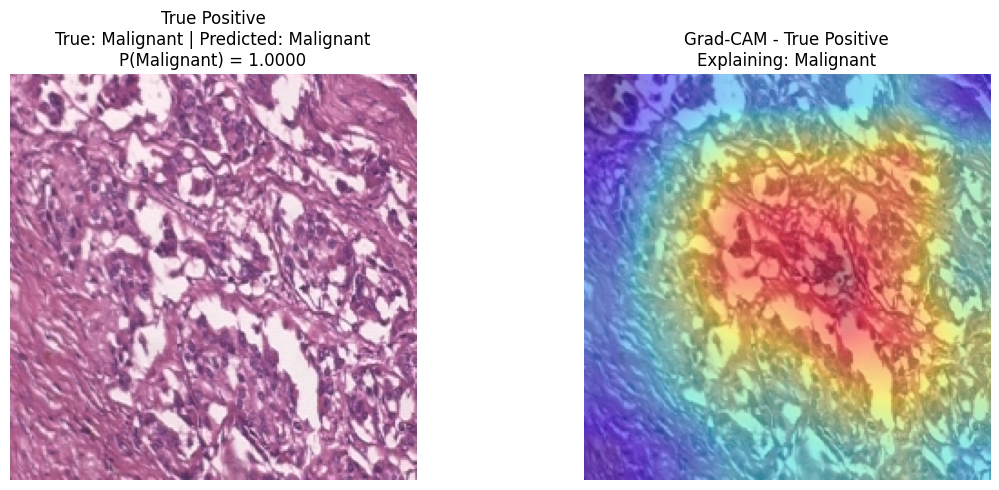

Saved: gradcam_class_specific_true_positive.png


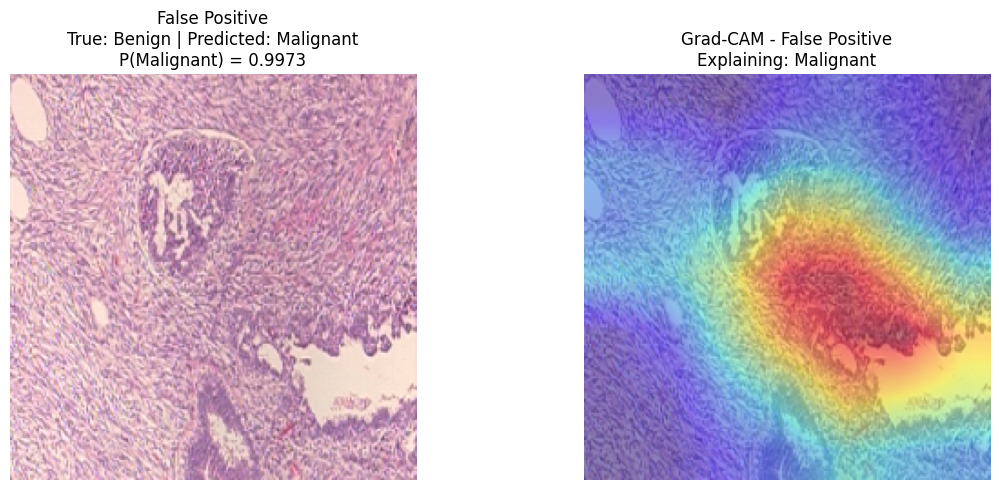

Saved: gradcam_class_specific_false_positive.png


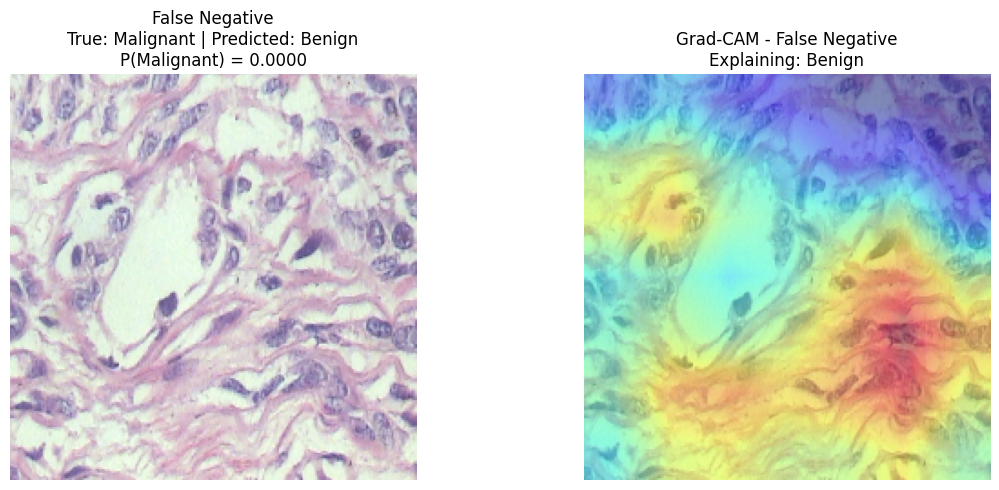

Saved: gradcam_class_specific_false_negative.png

Class-specific Grad-CAM generation completed.


In [55]:
# ============================================================
# REGENERATE CLASS-SPECIFIC GRAD-CAM VISUALIZATIONS
# ============================================================

for prediction_type, row in selected_examples.items():

    filepath = str(row["filepath"])

    # Load original image
    original_img = load_img(
        filepath,
        target_size=IMG_SIZE
    )

    original_array = img_to_array(
        original_img
    ).astype(np.float32)

    # Prepare image for ResNet50
    model_input = preprocess_input(
        original_array.copy()
    )

    model_input = np.expand_dims(
        model_input,
        axis=0
    )

    # --------------------------------------------------------
    # Explain the PREDICTED class
    # --------------------------------------------------------

    target_class = int(row["predicted_label"])

    heatmap = make_gradcam_heatmap_class_specific(
        model_input,
        fine_tune_model,
        target_class
    )

    # Resize heatmap
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        IMG_SIZE
    ).numpy().squeeze()

    # Class names
    true_class_name = (
        "Benign"
        if int(row["label"]) == 0
        else "Malignant"
    )

    predicted_class_name = (
        "Benign"
        if int(row["predicted_label"]) == 0
        else "Malignant"
    )

    target_class_name = predicted_class_name

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5)
    )

    # Original image
    axes[0].imshow(
        original_array.astype(np.uint8)
    )

    axes[0].set_title(
        f"{prediction_type}\n"
        f"True: {true_class_name} | "
        f"Predicted: {predicted_class_name}\n"
        f"P(Malignant) = "
        f"{row['probability_malignant']:.4f}"
    )

    axes[0].axis("off")

    # Grad-CAM
    axes[1].imshow(
        original_array.astype(np.uint8)
    )

    axes[1].imshow(
        heatmap_resized,
        alpha=0.45,
        cmap="jet"
    )

    axes[1].set_title(
        f"Grad-CAM - {prediction_type}\n"
        f"Explaining: {target_class_name}"
    )

    axes[1].axis("off")

    plt.tight_layout()

    # Save
    safe_name = (
        prediction_type
        .lower()
        .replace(" ", "_")
    )

    output_filename = (
        f"gradcam_class_specific_{safe_name}.png"
    )

    plt.savefig(
        output_filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved: {output_filename}"
    )

print("\nClass-specific Grad-CAM generation completed.")

In [56]:
# ============================================================
# ERROR ANALYSIS - FINE-TUNED RESNET50
# ============================================================

import pandas as pd
import numpy as np

# Use the existing Grad-CAM dataframe
error_df = gradcam_df.copy()

# ------------------------------------------------------------
# 1. Mark correct / incorrect predictions
# ------------------------------------------------------------

error_df["correct"] = (
    error_df["label"] == error_df["predicted_label"]
)

error_df["error_type"] = "Correct"

error_df.loc[
    (error_df["label"] == 0) &
    (error_df["predicted_label"] == 1),
    "error_type"
] = "False Positive"

error_df.loc[
    (error_df["label"] == 1) &
    (error_df["predicted_label"] == 0),
    "error_type"
] = "False Negative"

# ------------------------------------------------------------
# 2. Magnification
# ------------------------------------------------------------

error_df["magnification"] = (
    error_df["mag"].astype(str) + "X"
)

# ------------------------------------------------------------
# 3. Histological subtype
# ------------------------------------------------------------

error_df["subtype"] = error_df["filepath"].str.extract(
    r"breast/(?:benign|malignant)/SOB/([^/]+)/",
    expand=False
)

# ------------------------------------------------------------
# 4. Overall error summary
# ------------------------------------------------------------

total_images = len(error_df)
correct_predictions = error_df["correct"].sum()
total_errors = total_images - correct_predictions

false_positives = (
    error_df["error_type"] == "False Positive"
).sum()

false_negatives = (
    error_df["error_type"] == "False Negative"
).sum()

print("=" * 70)
print("ERROR ANALYSIS SUMMARY")
print("=" * 70)

print(f"Total test images:       {total_images}")
print(f"Correct predictions:     {correct_predictions}")
print(f"Total errors:            {total_errors}")
print(
    f"Overall error rate:      "
    f"{total_errors / total_images:.4f} "
    f"({total_errors / total_images * 100:.2f}%)"
)
print(f"False positives:         {false_positives}")
print(f"False negatives:         {false_negatives}")


# ============================================================
# 5. Error rate by magnification
# ============================================================

print("\n" + "=" * 70)
print("ERROR RATE BY MAGNIFICATION")
print("=" * 70)

magnification_summary = (
    error_df
    .groupby("magnification")
    .agg(
        Total_Images=("label", "size"),
        Errors=("correct", lambda x: (~x).sum())
    )
)

magnification_summary["Error_Rate"] = (
    magnification_summary["Errors"] /
    magnification_summary["Total_Images"]
)

magnification_summary["Error_Rate_Percent"] = (
    magnification_summary["Error_Rate"] * 100
)

display(
    magnification_summary.sort_index().style.format({
        "Error_Rate": "{:.4f}",
        "Error_Rate_Percent": "{:.2f}"
    })
)


# ============================================================
# 6. False positives by benign subtype
# ============================================================

print("\n" + "=" * 70)
print("FALSE POSITIVES BY BENIGN SUBTYPE")
print("=" * 70)

false_positive_df = error_df[
    error_df["error_type"] == "False Positive"
].copy()

fp_subtype = (
    false_positive_df
    .groupby("subtype")
    .size()
    .sort_values(ascending=False)
    .to_frame("False_Positives")
)

display(fp_subtype)


# ============================================================
# 7. False negatives by malignant subtype
# ============================================================

print("\n" + "=" * 70)
print("FALSE NEGATIVES BY MALIGNANT SUBTYPE")
print("=" * 70)

false_negative_df = error_df[
    error_df["error_type"] == "False Negative"
].copy()

fn_subtype = (
    false_negative_df
    .groupby("subtype")
    .size()
    .sort_values(ascending=False)
    .to_frame("False_Negatives")
)

display(fn_subtype)


# ============================================================
# 8. False positives by magnification
# ============================================================

print("\n" + "=" * 70)
print("FALSE POSITIVES BY MAGNIFICATION")
print("=" * 70)

fp_mag = (
    false_positive_df
    .groupby("magnification")
    .size()
    .sort_index()
    .to_frame("False_Positives")
)

display(fp_mag)


# ============================================================
# 9. False negatives by magnification
# ============================================================

print("\n" + "=" * 70)
print("FALSE NEGATIVES BY MAGNIFICATION")
print("=" * 70)

fn_mag = (
    false_negative_df
    .groupby("magnification")
    .size()
    .sort_index()
    .to_frame("False_Negatives")
)

display(fn_mag)


# ============================================================
# 10. Highest-confidence false positives
# ============================================================

print("\n" + "=" * 70)
print("HIGH-CONFIDENCE FALSE POSITIVES")
print("=" * 70)

high_conf_fp = (
    false_positive_df
    .sort_values(
        "probability_malignant",
        ascending=False
    )
)

display(
    high_conf_fp[
        [
            "filepath",
            "patient_id",
            "magnification",
            "subtype",
            "probability_malignant"
        ]
    ].head(10)
)


# ============================================================
# 11. Highest-confidence false negatives
# ============================================================

print("\n" + "=" * 70)
print("HIGH-CONFIDENCE FALSE NEGATIVES")
print("=" * 70)

high_conf_fn = (
    false_negative_df
    .assign(
        confidence_error=lambda x:
        1 - x["probability_malignant"]
    )
    .sort_values(
        "confidence_error",
        ascending=False
    )
)

display(
    high_conf_fn[
        [
            "filepath",
            "patient_id",
            "magnification",
            "subtype",
            "probability_malignant"
        ]
    ].head(10)
)


# ============================================================
# 12. Save results
# ============================================================

magnification_summary.to_csv(
    "error_analysis_by_magnification.csv"
)

fp_subtype.to_csv(
    "false_positives_by_subtype.csv"
)

fn_subtype.to_csv(
    "false_negatives_by_subtype.csv"
)

fp_mag.to_csv(
    "false_positives_by_magnification.csv"
)

fn_mag.to_csv(
    "false_negatives_by_magnification.csv"
)

print("\nError-analysis tables saved successfully.")

ERROR ANALYSIS SUMMARY
Total test images:       2904
Correct predictions:     2527
Total errors:            377
Overall error rate:      0.1298 (12.98%)
False positives:         116
False negatives:         261

ERROR RATE BY MAGNIFICATION


,Total_Images,Errors,Error_Rate,Error_Rate_Percent
magnification,,,,
100X,760,115,0.1513,15.13
200X,744,70,0.0941,9.41
400X,655,89,0.1359,13.59
40X,745,103,0.1383,13.83



FALSE POSITIVES BY BENIGN SUBTYPE


,False_Positives
subtype,
phyllodes_tumor,52
adenosis,34
tubular_adenoma,29
fibroadenoma,1



FALSE NEGATIVES BY MALIGNANT SUBTYPE


...


HIGH-CONFIDENCE FALSE POSITIVES


,filepath,patient_id,magnification,subtype,probability_malignant
686,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_B_PT_14-21998AB,40X,phyllodes_tumor,0.997332
687,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_B_PT_14-21998AB,40X,phyllodes_tumor,0.994753
734,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_B_PT_14-21998AB,400X,phyllodes_tumor,0.994038
124,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_B_A_14-22549G,400X,adenosis,0.991848
750,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_B_PT_14-21998AB,400X,phyllodes_tumor,0.990417
69,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_B_A_14-22549G,40X,adenosis,0.990266
694,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_B_PT_14-21998AB,40X,phyllodes_tumor,0.990200
689,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_B_PT_14-21998AB,40X,phyllodes_tumor,0.989560
631,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_B_PT_14-21998AB,200X,phyllodes_tumor,0.988217
579,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_B_PT_14-21998AB,100X,phyllodes_tumor,0.984843



HIGH-CONFIDENCE FALSE NEGATIVES


,filepath,patient_id,magnification,subtype,probability_malignant
2773,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_M_PC_14-15687B,400X,papillary_carcinoma,1.810357e-09
2767,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_M_PC_14-15687B,400X,papillary_carcinoma,3.317230e-09
2766,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_M_PC_14-15687B,400X,papillary_carcinoma,3.925816e-08
2770,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_M_PC_14-15687B,400X,papillary_carcinoma,4.213868e-07
1989,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_M_DC_14-3909,40X,ductal_carcinoma,1.004663e-06
2739,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_M_PC_14-15687B,200X,papillary_carcinoma,2.160498e-06
2765,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_M_PC_14-15687B,400X,papillary_carcinoma,3.092575e-06
2743,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_M_PC_14-15687B,200X,papillary_carcinoma,3.498235e-06
2772,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_M_PC_14-15687B,400X,papillary_carcinoma,3.756502e-06
1953,/root/.cache/kagglehub/datasets/ambarish/break...,SOB_M_DC_14-3909,100X,ductal_carcinoma,3.829861e-06



Error-analysis tables saved successfully.


In [57]:
# ============================================================
# NORMALIZED ERROR RATES
# ============================================================

# ------------------------------------------------------------
# 1. Overall error rate by magnification
# ------------------------------------------------------------

magnification_rates = (
    error_df
    .groupby("magnification")
    .agg(
        Total_Images=("label", "size"),
        Errors=("correct", lambda x: (~x).sum())
    )
    .reset_index()
)

magnification_rates["Error_Rate"] = (
    magnification_rates["Errors"] /
    magnification_rates["Total_Images"]
)

magnification_rates["Error_Rate_%"] = (
    magnification_rates["Error_Rate"] * 100
)

print("=" * 70)
print("NORMALIZED ERROR RATE BY MAGNIFICATION")
print("=" * 70)

display(
    magnification_rates.style.format({
        "Error_Rate": "{:.4f}",
        "Error_Rate_%": "{:.2f}"
    })
)


# ============================================================
# 2. False-positive rate within each benign subtype
# ============================================================

benign_df = error_df[
    error_df["label"] == 0
].copy()

benign_subtype_rates = (
    benign_df
    .groupby("subtype")
    .agg(
        Total_Benign_Images=("label", "size"),
        False_Positives=("error_type", lambda x:
                         (x == "False Positive").sum())
    )
    .reset_index()
)

benign_subtype_rates["False_Positive_Rate"] = (
    benign_subtype_rates["False_Positives"] /
    benign_subtype_rates["Total_Benign_Images"]
)

benign_subtype_rates["False_Positive_Rate_%"] = (
    benign_subtype_rates["False_Positive_Rate"] * 100
)

benign_subtype_rates = benign_subtype_rates.sort_values(
    "False_Positive_Rate",
    ascending=False
)

print("\n" + "=" * 70)
print("FALSE-POSITIVE RATE BY BENIGN SUBTYPE")
print("=" * 70)

display(
    benign_subtype_rates.style.format({
        "False_Positive_Rate": "{:.4f}",
        "False_Positive_Rate_%": "{:.2f}"
    })
)


# ============================================================
# 3. False-negative rate within each malignant subtype
# ============================================================

malignant_df = error_df[
    error_df["label"] == 1
].copy()

malignant_subtype_rates = (
    malignant_df
    .groupby("subtype")
    .agg(
        Total_Malignant_Images=("label", "size"),
        False_Negatives=("error_type", lambda x:
                         (x == "False Negative").sum())
    )
    .reset_index()
)

malignant_subtype_rates["False_Negative_Rate"] = (
    malignant_subtype_rates["False_Negatives"] /
    malignant_subtype_rates["Total_Malignant_Images"]
)

malignant_subtype_rates["False_Negative_Rate_%"] = (
    malignant_subtype_rates["False_Negative_Rate"] * 100
)

malignant_subtype_rates = malignant_subtype_rates.sort_values(
    "False_Negative_Rate",
    ascending=False
)

print("\n" + "=" * 70)
print("FALSE-NEGATIVE RATE BY MALIGNANT SUBTYPE")
print("=" * 70)

display(
    malignant_subtype_rates.style.format({
        "False_Negative_Rate": "{:.4f}",
        "False_Negative_Rate_%": "{:.2f}"
    })
)


# ============================================================
# 4. Save normalized analysis
# ============================================================

magnification_rates.to_csv(
    "normalized_error_rate_by_magnification.csv",
    index=False
)

benign_subtype_rates.to_csv(
    "benign_subtype_false_positive_rates.csv",
    index=False
)

malignant_subtype_rates.to_csv(
    "malignant_subtype_false_negative_rates.csv",
    index=False
)

print("\nNormalized error-analysis results saved.")

NORMALIZED ERROR RATE BY MAGNIFICATION


,magnification,Total_Images,Errors,Error_Rate,Error_Rate_%
0,100X,760,115,0.1513,15.13
1,200X,744,70,0.0941,9.41
2,400X,655,89,0.1359,13.59
3,40X,745,103,0.1383,13.83



FALSE-POSITIVE RATE BY BENIGN SUBTYPE


,subtype,Total_Benign_Images,False_Positives,False_Positive_Rate,False_Positive_Rate_%
2,phyllodes_tumor,235,52,0.2213,22.13
0,adenosis,191,34,0.1780,17.80
3,tubular_adenoma,251,29,0.1155,11.55
1,fibroadenoma,331,1,0.0030,0.30



FALSE-NEGATIVE RATE BY MALIGNANT SUBTYPE


,subtype,Total_Malignant_Images,False_Negatives,False_Negative_Rate,False_Negative_Rate_%
3,papillary_carcinoma,189,75,0.3968,39.68
2,mucinous_carcinoma,245,68,0.2776,27.76
1,lobular_carcinoma,324,34,0.1049,10.49
0,ductal_carcinoma,1138,84,0.0738,7.38



Normalized error-analysis results saved.


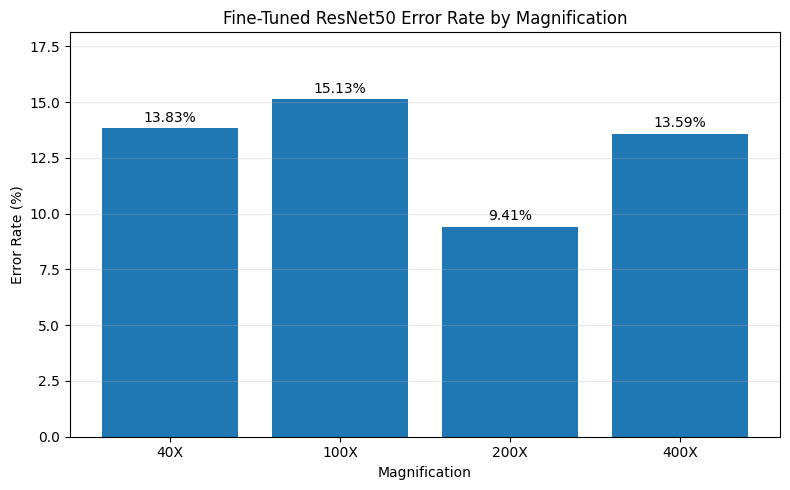

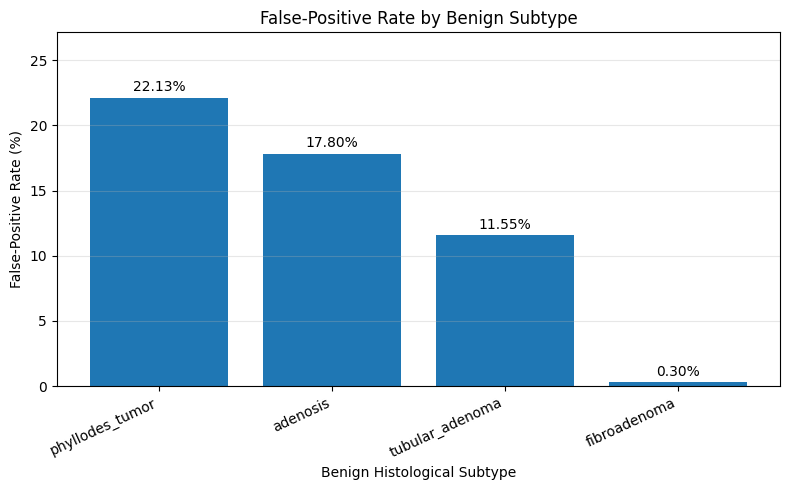

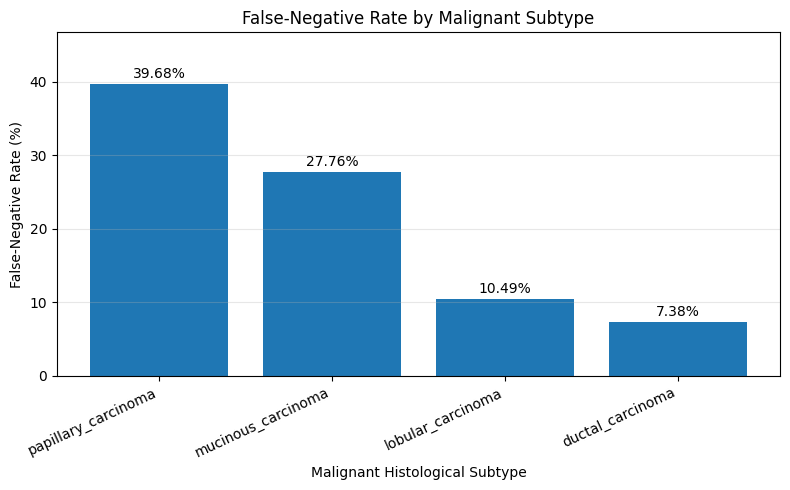

All error-analysis figures saved successfully.


In [58]:
# ============================================================
# REPORT-READY ERROR ANALYSIS FIGURES
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Error rate by magnification
# ------------------------------------------------------------

plot_mag = magnification_rates.copy()

# Order magnifications numerically
mag_order = ["40X", "100X", "200X", "400X"]

plot_mag["magnification"] = pd.Categorical(
    plot_mag["magnification"],
    categories=mag_order,
    ordered=True
)

plot_mag = plot_mag.sort_values("magnification")

plt.figure(figsize=(8, 5))

plt.bar(
    plot_mag["magnification"],
    plot_mag["Error_Rate_%"]
)

for i, value in enumerate(plot_mag["Error_Rate_%"]):
    plt.text(
        i,
        value + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

plt.xlabel("Magnification")
plt.ylabel("Error Rate (%)")
plt.title("Fine-Tuned ResNet50 Error Rate by Magnification")
plt.ylim(0, max(plot_mag["Error_Rate_%"]) + 3)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "error_rate_by_magnification.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 2. False-positive rate by benign subtype
# ------------------------------------------------------------

plot_fp = benign_subtype_rates.copy()

plt.figure(figsize=(8, 5))

plt.bar(
    plot_fp["subtype"],
    plot_fp["False_Positive_Rate_%"]
)

for i, value in enumerate(plot_fp["False_Positive_Rate_%"]):
    plt.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.xlabel("Benign Histological Subtype")
plt.ylabel("False-Positive Rate (%)")
plt.title("False-Positive Rate by Benign Subtype")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, max(plot_fp["False_Positive_Rate_%"]) + 5)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "false_positive_rate_by_benign_subtype.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 3. False-negative rate by malignant subtype
# ------------------------------------------------------------

plot_fn = malignant_subtype_rates.copy()

plt.figure(figsize=(8, 5))

plt.bar(
    plot_fn["subtype"],
    plot_fn["False_Negative_Rate_%"]
)

for i, value in enumerate(plot_fn["False_Negative_Rate_%"]):
    plt.text(
        i,
        value + 0.8,
        f"{value:.2f}%",
        ha="center"
    )

plt.xlabel("Malignant Histological Subtype")
plt.ylabel("False-Negative Rate (%)")
plt.title("False-Negative Rate by Malignant Subtype")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, max(plot_fn["False_Negative_Rate_%"]) + 7)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "false_negative_rate_by_malignant_subtype.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("All error-analysis figures saved successfully.")

In [59]:
# ============================================================
# FINAL EXPERIMENT EXPORT
# ============================================================

import os
import json
import numpy as np
import pandas as pd

print("=" * 80)
print("FINAL EXPERIMENT EXPORT")
print("=" * 80)

# ------------------------------------------------------------
# 1. Save the three trained models
# ------------------------------------------------------------

baseline_model.save("FINAL_Baseline_ResNet50.keras")
weighted_model.save("FINAL_ClassWeighted_ResNet50.keras")
fine_tune_model.save("FINAL_FineTuned_ResNet50.keras")

print("\nModels saved:")
print("1. FINAL_Baseline_ResNet50.keras")
print("2. FINAL_ClassWeighted_ResNet50.keras")
print("3. FINAL_FineTuned_ResNet50.keras")


# ------------------------------------------------------------
# 2. Final model comparison table
# ------------------------------------------------------------

final_results = comparison_results.copy()

final_results["Accuracy_%"] = final_results["Accuracy"] * 100
final_results["Balanced_Accuracy_%"] = (
    final_results["Balanced Accuracy"] * 100
)
final_results["Specificity_%"] = (
    final_results["Specificity"] * 100
)
final_results["Malignant_Recall_%"] = (
    final_results["Malignant Recall"] * 100
)
final_results["Benign_Recall_%"] = (
    final_results["Benign Recall"] * 100
)

final_results = final_results[
    [
        "Model",
        "Accuracy_%",
        "Balanced_Accuracy_%",
        "Specificity_%",
        "Malignant_Recall_%",
        "Benign_Recall_%",
        "Macro F1",
        "ROC-AUC",
        "PR-AUC"
    ]
]

final_results.to_csv(
    "FINAL_MODEL_COMPARISON.csv",
    index=False
)

print("\nFinal comparison saved.")


# ------------------------------------------------------------
# 3. Detailed confusion matrices
# ------------------------------------------------------------

confusion_summary = pd.DataFrame([
    {
        "Model": "Baseline ResNet50",
        "TN": baseline_test_results["confusion_matrix"][0, 0],
        "FP": baseline_test_results["confusion_matrix"][0, 1],
        "FN": baseline_test_results["confusion_matrix"][1, 0],
        "TP": baseline_test_results["confusion_matrix"][1, 1]
    },
    {
        "Model": "Class-Weighted ResNet50",
        "TN": weighted_test_results["confusion_matrix"][0, 0],
        "FP": weighted_test_results["confusion_matrix"][0, 1],
        "FN": weighted_test_results["confusion_matrix"][1, 0],
        "TP": weighted_test_results["confusion_matrix"][1, 1]
    },
    {
        "Model": "Fine-Tuned ResNet50",
        "TN": finetune_test_results["confusion_matrix"][0, 0],
        "FP": finetune_test_results["confusion_matrix"][0, 1],
        "FN": finetune_test_results["confusion_matrix"][1, 0],
        "TP": finetune_test_results["confusion_matrix"][1, 1]
    }
])

confusion_summary.to_csv(
    "FINAL_CONFUSION_MATRICES.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Save all final test predictions
# ------------------------------------------------------------

prediction_export = fold1_test.copy()

prediction_export["Baseline_Probability"] = (
    baseline_test_results["y_prob"]
)

prediction_export["Baseline_Prediction"] = (
    baseline_test_results["y_pred"]
)

prediction_export["ClassWeighted_Probability"] = (
    weighted_test_results["y_prob"]
)

prediction_export["ClassWeighted_Prediction"] = (
    weighted_test_results["y_pred"]
)

prediction_export["FineTuned_Probability"] = (
    finetune_test_results["y_prob"]
)

prediction_export["FineTuned_Prediction"] = (
    finetune_test_results["y_pred"]
)

prediction_export.to_csv(
    "FINAL_TEST_PREDICTIONS.csv",
    index=False
)


# ------------------------------------------------------------
# 5. Save error analysis
# ------------------------------------------------------------

error_df.to_csv(
    "FINAL_ERROR_ANALYSIS.csv",
    index=False
)

magnification_rates.to_csv(
    "FINAL_ERROR_BY_MAGNIFICATION.csv",
    index=False
)

benign_subtype_rates.to_csv(
    "FINAL_BENIGN_SUBTYPE_FALSE_POSITIVE_RATES.csv",
    index=False
)

malignant_subtype_rates.to_csv(
    "FINAL_MALIGNANT_SUBTYPE_FALSE_NEGATIVE_RATES.csv",
    index=False
)


# ------------------------------------------------------------
# 6. Save threshold analysis
# ------------------------------------------------------------

threshold_df.to_csv(
    "FINAL_VALIDATION_THRESHOLD_ANALYSIS.csv",
    index=False
)


# ------------------------------------------------------------
# 7. Determine best validation epoch
# ------------------------------------------------------------

def get_best_epoch(history):
    values = history.history["val_auc"]
    best_index = int(np.argmax(values))
    return {
        "best_epoch": best_index + 1,
        "best_val_auc": float(values[best_index])
    }


baseline_training_summary = get_best_epoch(
    history_baseline
)

weighted_training_summary = get_best_epoch(
    history_weighted
)

finetune_training_summary = get_best_epoch(
    history_finetune
)


# ------------------------------------------------------------
# 8. Create experiment metadata
# ------------------------------------------------------------

experiment_metadata = {
    "dataset": "BreakHis",
    "total_images": 7909,
    "total_patients": 82,
    "fold_used": 1,

    "train_patients": int(train_df["patient_id"].nunique()),
    "validation_patients": int(val_df["patient_id"].nunique()),
    "test_patients": int(fold1_test["patient_id"].nunique()),

    "train_images": int(len(train_df)),
    "validation_images": int(len(val_df)),
    "test_images": int(len(fold1_test)),

    "train_benign_images": int(
        (train_df["label"] == 0).sum()
    ),
    "train_malignant_images": int(
        (train_df["label"] == 1).sum()
    ),

    "validation_benign_images": int(
        (val_df["label"] == 0).sum()
    ),
    "validation_malignant_images": int(
        (val_df["label"] == 1).sum()
    ),

    "test_benign_images": int(
        (fold1_test["label"] == 0).sum()
    ),
    "test_malignant_images": int(
        (fold1_test["label"] == 1).sum()
    ),

    "image_size": "224x224x3",
    "batch_size": 32,
    "preprocessing": "ResNet50 preprocess_input",

    "class_weights": {
        "benign": float(class_weights[0]),
        "malignant": float(class_weights[1])
    },

    "baseline_best_epoch": baseline_training_summary["best_epoch"],
    "baseline_best_val_auc": baseline_training_summary["best_val_auc"],

    "class_weighted_best_epoch": weighted_training_summary["best_epoch"],
    "class_weighted_best_val_auc": weighted_training_summary["best_val_auc"],

    "finetuned_best_epoch": finetune_training_summary["best_epoch"],
    "finetuned_best_val_auc": finetune_training_summary["best_val_auc"],

    "baseline_test_accuracy": float(
        baseline_test_results["accuracy"]
    ),
    "class_weighted_test_accuracy": float(
        weighted_test_results["accuracy"]
    ),
    "finetuned_test_accuracy": float(
        finetune_test_results["accuracy"]
    ),

    "baseline_test_balanced_accuracy": float(
        baseline_test_results["balanced_accuracy"]
    ),
    "class_weighted_test_balanced_accuracy": float(
        weighted_test_results["balanced_accuracy"]
    ),
    "finetuned_test_balanced_accuracy": float(
        finetune_test_results["balanced_accuracy"]
    ),

    "baseline_roc_auc": float(
        baseline_test_results["roc_auc"]
    ),
    "class_weighted_roc_auc": float(
        weighted_test_results["roc_auc"]
    ),
    "finetuned_roc_auc": float(
        finetune_test_results["roc_auc"]
    ),

    "baseline_pr_auc": float(
        baseline_test_results["pr_auc"]
    ),
    "class_weighted_pr_auc": float(
        weighted_test_results["pr_auc"]
    ),
    "finetuned_pr_auc": float(
        finetune_test_results["pr_auc"]
    ),

    "validation_selected_threshold": float(
        best_threshold
    ),

    "patient_overlap_train_validation": 0,
    "patient_overlap_train_test": 0,
    "patient_overlap_validation_test": 0
}

with open(
    "FINAL_EXPERIMENT_METADATA.json",
    "w"
) as f:
    json.dump(
        experiment_metadata,
        f,
        indent=4
    )


# ------------------------------------------------------------
# 9. Final verification
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL DATASET CONFIGURATION")
print("=" * 80)

print(f"Train:       {len(train_df)} images / "
      f"{train_df['patient_id'].nunique()} patients")

print(f"Validation:  {len(val_df)} images / "
      f"{val_df['patient_id'].nunique()} patients")

print(f"Test:        {len(fold1_test)} images / "
      f"{fold1_test['patient_id'].nunique()} patients")

print("\nPatient overlap:")
print("Train-Val : 0")
print("Train-Test: 0")
print("Val-Test  : 0")


print("\n" + "=" * 80)
print("FINAL TEST RESULTS")
print("=" * 80)

display(
    final_results.style.format({
        "Accuracy_%": "{:.2f}",
        "Balanced_Accuracy_%": "{:.2f}",
        "Specificity_%": "{:.2f}",
        "Malignant_Recall_%": "{:.2f}",
        "Benign_Recall_%": "{:.2f}",
        "Macro F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}"
    })
)

print("\n" + "=" * 80)
print("EXPORT COMPLETED")
print("=" * 80)

print("Models, predictions, metrics, threshold analysis,")
print("error analysis and metadata have been saved.")

FINAL EXPERIMENT EXPORT

Models saved:
1. FINAL_Baseline_ResNet50.keras
2. FINAL_ClassWeighted_ResNet50.keras
3. FINAL_FineTuned_ResNet50.keras

Final comparison saved.

FINAL DATASET CONFIGURATION
Train:       4088 images / 43 patients
Validation:  917 images / 11 patients
Test:        2904 images / 28 patients

Patient overlap:
Train-Val : 0
Train-Test: 0
Val-Test  : 0

FINAL TEST RESULTS


,Model,Accuracy_%,Balanced_Accuracy_%,Specificity_%,Malignant_Recall_%,Benign_Recall_%,Macro F1,ROC-AUC,PR-AUC
0,Baseline ResNet50,86.78,84.30,76.19,92.41,76.19,0.8506,0.9338,0.9644
1,Class-Weighted ResNet50,86.64,86.14,84.52,87.76,84.52,0.8551,0.9321,0.9640
2,Fine-Tuned ResNet50,87.02,87.36,88.49,86.23,88.49,0.8611,0.9426,0.9704



EXPORT COMPLETED
Models, predictions, metrics, threshold analysis,
error analysis and metadata have been saved.
